# HotpotQA 无训练语义校正对比 (LLM Anchor + kNN 传播)

本 notebook 复现 `cross-encoder refine.docx` 提出的**无训练语义校正**方法，并与既有方法对比。
基础设施（scan cache 载入、span 嵌入、共享 Wikidata 候选库、Full CE、FFT-CE、FFT-LLM、LLM 全量标注）
直接复用 `hotpotqa_fft_span_compare.ipynb` 的实现，保证候选库与 weak gold 完全一致、可直接比较。

## 对比的方法

- **Full CE**：每个 occurrence 直接取 cross-encoder top-1。(docx Version A)
- **FFT-CE**：现行系统的 FFT 采样 + consensus/split + KNN safety + medoid/d1-d2 传播 + CE 兜底。(docx Version B)
- **FFT-LLM**：同一算法骨架，但样本判定由 LLM 取代 CE。
- **新方法消融阶梯**（docx Version C→F），均以少量 **LLM anchor** 为锚点在 embedding kNN 图上传播。anchor 的选择先用 FFT 覆盖 embedding 空间中的边界/离群点，再补少量 random 样本；anchor 标签来自 LLM。随后算法只在同一个 span 的 occurrence 图上做标签传播，不训练新模型。

### C：LLM anchor + plain kNN vote

C 是最基础的 anchor 传播版本。先为所有 occurrence 建立 embedding kNN 图；这里的 plain kNN 会把近邻关系当作无向边使用，只要 `i` 把 `j` 视为近邻，二者就连边，不要求 `j` 也把 `i` 视为近邻。传播从 LLM 标注过的 anchor 出发，逐轮查看未标注点的已标注近邻；如果某个语义描述拿到足够多数票（`PROP_VOTE_RATIO`），就把该描述赋给当前 occurrence。C 不使用 CE margin 反对票，也不检查 anchor center，因此它更激进，覆盖率通常更高，但也更容易把局部错误沿 kNN 边扩散。

### D：LLM anchor + mutual-kNN vote

D 只改变图结构：把 C 的 plain kNN 换成 mutual-kNN。只有当 `i` 和 `j` 互相出现在对方的 top-k 近邻里时，二者才连边。这个版本的目标是减少非对称近邻造成的错误传播，让标签只沿更可信的局部邻域扩散。代价是图会更稀疏，anchor 标签可能传不到边界点或稀疏区域；因此 D 通常更保守，uncertain 更多，也可能保留更多 CE 原始错误。

### E：kNN vote + CE margin veto

E 在 anchor 传播上加入 cross-encoder margin 作为反对票。本实验分别测试 plain kNN vote 和 mutual-kNN vote 两种图结构。每个 occurrence 仍先有 Full CE 的候选分数和 top-1；如果近邻多数标签与 CE top-1 冲突，且 CE 的 top1-top2 margin 高于 `PROP_HIGH_MARGIN`，同时 CE 对近邻多数标签的分数比 top-1 低至少 `PROP_CE_OPPOSE_GAP`，则认为 CE 强烈反对这次覆盖，当前点暂不接受近邻标签。直觉是：CE 不自信时允许图传播纠错，CE 很自信时防止近邻投票把原本正确的点改错。这个版本需要全量 CE 分数，因此成本更高。

### F：E + anchor center + rare-class conservative + uncertain

F 是完整版本，在 E 的基础上增加三层保护，并同样分别测试 plain kNN vote 和 mutual-kNN vote。第一，按 anchor 标签计算每个语义类的 embedding center；当近邻多数标签与最近 anchor center 一致时，可以支持弱多数投票（`PROP_WEAK_VOTE_RATIO`），也可以在 CE veto 冲突时作为 `center_override` 的证据。第二，如果某个类在 anchor 中样本数很少（`PROP_RARE_ANCHOR_THRESHOLD`），就把它当作稀有类，传播时要求更高投票比例（`PROP_RARE_VOTE_RATIO`），并尽量要求 center 或 CE 支撑，避免稀有类被少量近邻误扩散。第三，对传播结束后仍无可靠标签的 occurrence 标记为 uncertain，再交给两种收尾策略处理：CE 兜底或再次询问 LLM。

每个新方法版本都跑 **uncertain 的两种收尾**：`ce_fallback`（CE top-1 兜底）/ `re_llm`（再问 LLM）。E 和 F 额外各跑 plain kNN vote 与 mutual-kNN vote，因此每个都有 4 种变体。

## 评测口径

- weak gold = 用同一 LLM 对**全部** occurrence 全量标注（`classify_records_with_llm`）。
- accuracy 同时报 **overall**（含 anchor）与 **propagation-only**（去掉 anchor，反映传播本身质量）。
- 其它指标：macro-F1 / per-class F1 / rare-class recall·precision / uncertain 比例 /
  **corrected CE error**（CE 原本错、被本方法改对）/ **newly introduced error**（CE 原本对、被本方法改错）/
  LLM 调用计数 / CE 调用计数。

> 注意两个评测局限（诚实标注，不作他用）：
> 1. anchor 标签复用与 weak gold 同一个 LLM + cache，所以 anchor 必然等于 gold；overall accuracy 会被 anchor 占比“垫高”，请以 propagation-only 衡量传播质量。
> 2. uncertain 的 `re_llm` 收尾在本评测里命中同一个 gold cache，相当于直接拿 gold，因此该收尾对 uncertain 必然正确，只用于估算“需要追加多少次 LLM 调用”的上限。

换词或调参请修改开头「全局实验参数」单元格，然后从上往下重新运行。


In [1]:
from pathlib import Path
import os
import sys

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "jupyter_notebooks":
    REPO_ROOT = REPO_ROOT.parent

os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Working directory: {REPO_ROOT}")

Working directory: /home/xiaoyue/LiteSemRAG


In [2]:
from collections import Counter, defaultdict
from pathlib import Path
import json
import pickle
import re
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import torch
from IPython.display import display
from sentence_transformers import CrossEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from transformers import AutoModel, AutoTokenizer

from text_processing import get_token_indices_for_phrase, normalize_text
from utils import (
    build_wikidata_candidate_bank as shared_build_wikidata_candidate_bank,
    extract_cross_encoder_scores,
    farthest_first_traversal,
    load_wikidata_definition_candidates as shared_load_wikidata_definition_candidates,
)
from utils import fetch_detailed_descriptions_for_entities
from wikidata_definition_filter import (
    MERGE_WITH_SAMPLES_SYSTEM_PROMPT,
    MERGE_WITH_SAMPLES_USER_PROMPT_TEMPLATE,
    WIKIDATA_CANDIDATE_MERGE_WITH_SAMPLES_VERSION,
    CandidateSense,
    WikidataDefinitionFilter,
    _build_definitions,
    _extract_json_object,
)
from llm_semantic_labeler import (
    DEFAULT_CACHE_PATH as DEFAULT_LLM_CACHE_PATH,
    DEFAULT_CONTEXT_WORD_WINDOW as DEFAULT_LLM_CONTEXT_WORD_WINDOW,
    DEFAULT_MAX_TOKENS as DEFAULT_LLM_MAX_TOKENS,
    choose_wikidata_candidate_with_llm,
)
from local_llm import LocalLLMClient, LocalLLMConfig
from sklearn.metrics import f1_score


In [3]:
# =============================================================================
# 全局实验参数（修改本单元格后，自上而下重新运行 notebook）
# =============================================================================

# --- 实验目标 ---
TARGET_SPAN = "space"  # 要分析的 query span / 目标词
QUERY_KIND = None  # Hotpot 记录类型过滤；None 表示 phrase+token 全部保留

# --- 数据与模型路径 ---
HOTPOT_SCAN_STORE_PATH = Path("hotpot_QA_qwen_scan_cache/hotpot_phrase_token_scan_store_qwen_scan_v1_all.pkl")  # HotpotQA scan 缓存
DEFAULT_CROSS_ENCODER_MODEL = "cross-encoder/nli-deberta-v3-large"  # cross-encoder 模型
DEFAULT_TEXT_ENCODER_NAME_OR_PATH = "/home/xiaoyue/ProtoGraphRAG/deberta-v3-large"  # span 嵌入用 DeBERTa

# --- 设备与显示 ---
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"  # 推理设备

# --- 嵌入与上下文 ---
INPUT_SAMPLE_LIMIT = 150  # 每个 query 最多载入多少条 occurrence
DEFAULT_BATCH_SIZE = 16  # 文本编码 batch 大小
DEFAULT_MAX_LENGTH = 512  # tokenizer 最大长度
DEFAULT_CONTEXT_MODE = "sentence_neighbors"  # 上下文窗口：sentence / sentence_neighbors / full_text
MARK_TARGET = False  # 是否在 context 里用 << >> 标出目标 span

# --- Wikidata 候选（非 LLM 规则路径） ---
WIKIDATA_CANDIDATE_LIMIT = 8  # Wikidata 原始候选上限
USE_DETAILED_DESCRIPTION = False  # 是否用 detailed_description 字段
REQUIRE_DETAILED_DESCRIPTION = True  # 规则过滤时是否要求有详细描述
EXACT_MATCH_TEXT = True  # 是否要求 label/alias 精确匹配 query
FILTER_NAME = False  # 是否启用名称/别名规则过滤

# --- LLM 候选合并（wikidata_llm_candidate_merge_experiment 同款） ---
USE_LLM_WIKIDATA = True  # True：FFT 引导的 merge_with_samples；False：仅规则过滤 Wikidata
LLM_WIKIDATA_USE_API = True  # True=OpenAI API；False=本地 OpenAI 兼容服务
LLM_WIKIDATA_MODEL = None  # None 则用 WikidataDefinitionFilter 默认模型
LLM_WIKIDATA_CACHE_PATH = Path("cache/wikidata_definition_filter_cache.sqlite3")  # filter 客户端缓存路径（合并本身不按 term 缓存）

# --- FFT-CE / FFT 传播共用 ---
DEFAULT_MAX_SAMPLES = 10  # FFT 最远点采样数量
FFT_LLM_MERGE_SAMPLE_COUNT = DEFAULT_MAX_SAMPLES  # 送入 LLM 合并候选的 FFT 样本数
DEFAULT_CONSENSUS_RATIO_THRESHOLD = 0.9  # FFT 种子 consensus 阈值
DEFAULT_D1_D2_RATIO_THRESHOLD = 0.8  # medoid 传播 d1/d2 比阈值
DEFAULT_FFT_KNN_CHECK_K = 5  # danger zone KNN 检查的 k
DEFAULT_FFT_DANGER_NEIGHBOR_M = 10  # danger zone 邻居数 m
CROSS_ENCODER_BATCH_SIZE = 32  # Full CE / danger-zone CE 的 batch

# --- weak gold：LLM 全量标注 ---
LLM_PROVIDER = "openai"  # weak gold LLM 提供商
LLM_MODEL = "gpt-5.4-mini"  # weak gold 模型名
LLM_API_KEY_FILE = "API_KEY"  # API key 文件路径
LLM_CACHE_PATH = Path("cache/llm_semantic_label_cache_gpt54mini_refresh.sqlite3")  # 逐条标注 SQLite 缓存
LLM_CONTEXT_WORD_WINDOW = DEFAULT_LLM_CONTEXT_WORD_WINDOW  # 裁切给 LLM 的上下文词数窗口
LLM_MAX_TOKENS = DEFAULT_LLM_MAX_TOKENS  # weak gold 最大生成 token

# --- FFT-LLM（采样后批量/单条 LLM 判定） ---
FFT_LLM_PROVIDER = "openai"  # FFT-LLM 提供商
FFT_LLM_MODEL = "gpt-5.4-mini"  # FFT-LLM 模型名
FFT_LLM_API_KEY_FILE = "API_KEY"  # FFT-LLM API key 文件
FFT_LLM_PROMPT_MODE = "batch"  # batch 或 single（仅影响 FFT 采样后的判定）
FFT_LLM_BATCH_SIZE = 10  # batch 模式下每批 record 数
FFT_LLM_MAX_TOKENS = 1024  # FFT-LLM 最大生成 token

FFT_LLM_BATCH_SYSTEM_PROMPT = """You are a precise semantic disambiguation assistant.
Choose exactly one Wikidata candidate for each target span record.
Return valid JSON only.
"""

FFT_LLM_BATCH_USER_PROMPT_TEMPLATE = """Candidate meanings:
{candidate_block}

Records to judge:
{record_block}

Instructions:
1. For each record, pick the single best candidate for matched_text in that context.
2. Prefer semantic fit to the local context over surface similarity.
3. Return JSON only in this shape:
{{"judgments": [{{"record_index": <integer>, "selected_index": <integer>, "reason": "<short explanation>"}}]}}
4. Include exactly one judgment for every input record_index and do not add extra record_index values.
"""

# --- 预留开关（当前 run cell 未分支使用，便于与 fft_span_compare 对齐） ---
ENABLE_LLM_VALIDATION = True  # 是否在评测里做 LLM 校验（预留）
ENABLE_FFT_LLM_EXPERIMENT = True  # 是否运行 FFT-LLM 分支（预留）
ENABLE_FFT_MERGE_EXPERIMENT = True  # 是否运行 combined merge 实验（预留）
FFT_MERGE_CANDIDATE_LIMIT = WIKIDATA_CANDIDATE_LIMIT  # combined merge 候选上限（预留）

# --- Anchor 传播（新方法 C/D/E/F） ---
UNCERTAIN_LABEL = "<<uncertain>>"  # 传播未能确定时的标签

ANCHOR_FRACTION = 0.15  # anchor 占全部 occurrence 的比例
ANCHOR_FFT_RATIO = 0.70  # anchor 中由 FFT 选出的比例（其余 random）
ANCHOR_MIN_COUNT = 2  # anchor 最少个数
ANCHOR_RANDOM_STATE = 42  # anchor 随机采样种子

PROP_KNN_K = 8  # 构图近邻数 k

PROP_VOTE_RATIO = 0.60  # 普通类采纳所需近邻多数比例
PROP_WEAK_VOTE_RATIO = 0.50  # 弱投票（需 anchor center）比例
PROP_RARE_VOTE_RATIO = 0.80  # 稀有类采纳所需更高比例

PROP_HIGH_MARGIN = 1.5  # CE margin 高于此视为“自信”（用于反对票）
PROP_LOW_MARGIN = 0.5  # CE margin 低于此视为“不自信”（备查）
PROP_CE_OPPOSE_GAP = 0.5  # CE 对多数类分数比 top1 低多少算强烈反对

PROP_RARE_ANCHOR_THRESHOLD = 2  # anchor 中样本数 ≤ 此值的类视为稀有类
RARE_GOLD_THRESHOLD = 5  # 评测：gold 中样本数 ≤ 此值的类视为稀有类

PROP_MAX_ROUNDS = 50  # 标签传播最大轮数

PROP_VERSIONS = ["C", "D", "E", "F"]  # 要跑的新方法版本
PROP_UNCERTAIN_MODES = ["ce_fallback", "re_llm"]  # uncertain 收尾模式

PROP_VERSION_FLAGS = {  # 各版本消融开关（kNN 类型单独由 PROP_VERSION_KNN_TYPES 控制）
    "C": dict(use_margin=False, use_center=False, rare_conservative=False),
    "D": dict(use_margin=False, use_center=False, rare_conservative=False),
    "E": dict(use_margin=True, use_center=False, rare_conservative=False),
    "F": dict(use_margin=True, use_center=True, rare_conservative=True),
}

PROP_VERSION_KNN_TYPES = {  # C/D 保持原设置；E/F 同时测试 plain 与 mutual
    "C": ["plain"],
    "D": ["mutual"],
    "E": ["plain", "mutual"],
    "F": ["plain", "mutual"],
}


def iter_anchor_prop_specs():
    for version in PROP_VERSIONS:
        for knn_type in PROP_VERSION_KNN_TYPES[version]:
            for uncertain_mode in PROP_UNCERTAIN_MODES:
                flags = dict(PROP_VERSION_FLAGS[version])
                flags["knn_type"] = knn_type
                yield version, knn_type, uncertain_mode, flags


def anchor_prop_key(version, knn_type, uncertain_mode):
    return (version, knn_type, uncertain_mode)


def anchor_method_name(version, knn_type, uncertain_mode):
    if version in {"E", "F"}:
        return f"Anchor-{version}-{knn_type} [{uncertain_mode}]"
    return f"Anchor-{version} [{uncertain_mode}]"

# --- 可视化 ---
DEFAULT_REDUCTION_METHOD = "tsne"  # 降维：pca 或 tsne
DEFAULT_RANDOM_STATE = 42  # t-SNE/PCA 随机种子

pd.set_option("display.max_colwidth", None)
print(f"Device: {DEVICE}")
print(f"Target span: {TARGET_SPAN!r}")


Device: cuda
Target span: 'space'


In [4]:
def load_hotpot_scan_store(scan_store_path: Path = HOTPOT_SCAN_STORE_PATH):
    if not scan_store_path.exists():
        raise FileNotFoundError(
            f"HotpotQA scan store not found at {scan_store_path}. Please prepare the scan cache first."
        )

    with scan_store_path.open("rb") as handle:
        store = pickle.load(handle)

    print(f"Loaded scan-only store from {scan_store_path}")
    print(store["stats"])
    return store


embedding_store = load_hotpot_scan_store()

Loaded scan-only store from hotpot_QA_qwen_scan_cache/hotpot_phrase_token_scan_store_qwen_scan_v1_all.pkl
{'num_documents': 4937, 'num_unique_terms': 60797, 'num_phrase_occurrences': 77703, 'num_token_occurrences': 93649, 'num_total_occurrences': 171352}


In [5]:
def lookup_records(store, query_text, kind=None, include_text=True, include_cleaned_text=True):
    normalized_query = normalize_text(query_text.strip())
    records = list(store["index"].get(normalized_query, []))

    if kind is not None:
        records = [record for record in records if record["kind"] == kind]

    if not include_text and not include_cleaned_text:
        return records

    enriched_records = []
    for record in records:
        item = dict(record)
        document_idx = item["document_idx"]
        if include_text:
            item["text"] = store["documents"][document_idx]["text"]
        if include_cleaned_text:
            item["cleaned_text"] = store["cleaned_documents"][document_idx]
        enriched_records.append(item)
    return enriched_records


def _find_left_boundary(text: str, index: int) -> int:
    return max(
        text.rfind(".", 0, index),
        text.rfind("!", 0, index),
        text.rfind("?", 0, index),
    )


def _find_right_boundary(text: str, index: int) -> int:
    right_candidates = [
        text.find(".", index),
        text.find("!", index),
        text.find("?", index),
    ]
    right_candidates = [idx for idx in right_candidates if idx != -1]
    return len(text) if not right_candidates else min(right_candidates) + 1


def _build_context_from_bounds(cleaned_text, span, context_start, context_end):
    start_char, end_char = span
    context_raw = cleaned_text[context_start:context_end]

    if not context_raw.strip():
        context_start = max(0, start_char - 120)
        context_end = min(len(cleaned_text), end_char + 120)
        context_raw = cleaned_text[context_start:context_end]

    left_trim = len(context_raw) - len(context_raw.lstrip())
    context_text = context_raw.strip()

    local_start = start_char - context_start - left_trim
    local_end = end_char - context_start - left_trim
    local_start = max(0, min(local_start, len(context_text)))
    local_end = max(local_start, min(local_end, len(context_text)))

    return {
        "context_text": context_text,
        "local_span": (local_start, local_end),
    }


def extract_sentence_context(cleaned_text, span):
    start_char, end_char = span
    left_boundary = _find_left_boundary(cleaned_text, start_char)
    context_start = 0 if left_boundary == -1 else left_boundary + 1
    context_end = _find_right_boundary(cleaned_text, end_char)
    return _build_context_from_bounds(cleaned_text, span, context_start, context_end)


def extract_neighbor_sentence_context(cleaned_text, span):
    start_char, end_char = span
    left_boundary = _find_left_boundary(cleaned_text, start_char)
    context_start = 0 if left_boundary == -1 else left_boundary + 1
    context_end = _find_right_boundary(cleaned_text, end_char)

    if context_start > 0:
        previous_boundary = _find_left_boundary(cleaned_text, max(0, context_start - 1))
        context_start = 0 if previous_boundary == -1 else previous_boundary + 1

    if context_end < len(cleaned_text):
        context_end = _find_right_boundary(cleaned_text, context_end)

    return _build_context_from_bounds(cleaned_text, span, context_start, context_end)


def extract_full_context(cleaned_text, span):
    start_char, end_char = span
    context_raw = cleaned_text
    left_trim = len(context_raw) - len(context_raw.lstrip())
    context_text = context_raw.strip()

    local_start = start_char - left_trim
    local_end = end_char - left_trim
    local_start = max(0, min(local_start, len(context_text)))
    local_end = max(local_start, min(local_end, len(context_text)))

    return {
        "context_text": context_text,
        "local_span": (local_start, local_end),
    }


def extract_prompt_context(cleaned_text, span, prompt_context_mode="sentence"):
    if prompt_context_mode == "sentence":
        return extract_sentence_context(cleaned_text, span)
    if prompt_context_mode == "full_text":
        return extract_full_context(cleaned_text, span)
    if prompt_context_mode == "sentence_neighbors":
        return extract_neighbor_sentence_context(cleaned_text, span)
    raise ValueError(
        f"Unsupported prompt_context_mode={prompt_context_mode!r}. Use 'sentence', 'sentence_neighbors', or 'full_text'."
    )


def build_hotpot_prompt(
    record,
    query_text,
    mark_target=False,
    left_marker="[TGT]",
    right_marker="[/TGT]",
    prompt_context_mode="sentence",
):
    context_info = extract_prompt_context(
        record["cleaned_text"],
        record["span"],
        prompt_context_mode=prompt_context_mode,
    )
    context_text = context_info["context_text"]
    local_start, local_end = context_info["local_span"]
    prompt_context = context_text

    if mark_target:
        prompt_context = (
            f"{context_text[:local_start]}{left_marker} {context_text[local_start:local_end]} {right_marker}{context_text[local_end:]}"
        )

    prompt_text = (
        f"Context: {prompt_context}\n"
        f"Target word: {query_text.strip()}\n\n"
        f'Question: What does "{query_text.strip()}" mean in this context?'
    )

    return {
        "context_text": context_text,
        "matched_text": context_text[local_start:local_end],
        "local_span": (local_start, local_end),
        "prompt_text": prompt_text,
    }


In [6]:
def load_wikidata_definition_candidates(
    query_text: str,
    use_detailed_description: bool = True,
    exact_match_text: bool = False,
    filter_name: bool = True,
    require_detailed_description: bool = False,
    candidate_limit: int = 5,
    use_span_rules: bool = True,
):
    return shared_load_wikidata_definition_candidates(
        query_text,
        use_detailed_description=use_detailed_description,
        exact_match_text=exact_match_text,
        limit=int(candidate_limit),
        filter_name=filter_name,
        require_detailed_description=require_detailed_description,
        target_candidate_count=int(candidate_limit),
        use_span_rules=use_span_rules,
        use_llm_filter=False,
    )


def fetch_raw_candidate_senses_for_merge(
    word: str,
    max_candidates: int,
    use_detailed_description: bool = False,
):
    """Raw Wikidata candidates (wikidata_llm_candidate_merge_experiment: use_span_rules=False)."""
    candidates_df, definition_column = load_wikidata_definition_candidates(
        word,
        use_detailed_description=use_detailed_description,
        use_span_rules=False,
        candidate_limit=max_candidates,
    )
    candidate_bank = shared_build_wikidata_candidate_bank(candidates_df, definition_column)
    rows = []
    for idx, candidate in enumerate(candidate_bank, start=1):
        rows.append(
            {
                "candidate_id": idx,
                "wikidata_id": candidate["entity_id"],
                "label": candidate["label"],
                "description": candidate["description"],
                "definition": candidate["definition"],
                "hypothesis": candidate["hypothesis"],
            }
        )
    return rows, candidates_df


def compact_candidates_for_merge_prompt(candidates: list[dict]) -> list[dict]:
    return [
        {
            "candidate_id": candidate["candidate_id"],
            "label": candidate["label"],
            "hypothesis": candidate["hypothesis"],
        }
        for candidate in candidates
    ]


def compact_fft_samples_for_merge_prompt(sample_records: list[dict]) -> list[dict]:
    rows = []
    for sample in sample_records:
        context_text = re.sub(r"\s+", " ", sample["context_text"]).strip()
        sample_order = sample.get("sample_order", sample.get("fft_sample_order"))
        rows.append(
            {
                "sample_order": sample_order,
                "title": sample.get("title"),
                "matched_text": sample["matched_text"],
                "context_text": context_text,
            }
        )
    return rows


def build_merge_prompt_for_candidates(word: str, candidates: list[dict], fft_samples: list[dict]) -> str:
    payload = {
        "word": word,
        "candidate_senses": compact_candidates_for_merge_prompt(candidates),
        "fft_dataset_samples": compact_fft_samples_for_merge_prompt(fft_samples),
    }
    return MERGE_WITH_SAMPLES_USER_PROMPT_TEMPLATE.format(
        candidate_payload=json.dumps(payload, ensure_ascii=False, indent=2)
    )


def candidate_senses_to_filter_candidates(candidate_senses: list[dict]) -> list[CandidateSense]:
    return [
        CandidateSense(
            index=int(item["candidate_id"]) - 1,
            entity_id=str(item["wikidata_id"]),
            label=str(item["label"]),
            description=str(item.get("description", "") or ""),
            detailed_description="",
            definition=str(item.get("definition", "") or ""),
            hypothesis=str(item.get("hypothesis", "") or ""),
        )
        for item in candidate_senses
    ]


def merge_candidate_senses_with_fft_samples(
    word: str,
    candidate_senses: list[dict],
    fft_samples: list[dict],
    llm_filter: WikidataDefinitionFilter,
):
    """LLM merge using the same prompt/method as wikidata_llm_candidate_merge_experiment.ipynb."""
    filter_candidates = candidate_senses_to_filter_candidates(candidate_senses)
    user_prompt = build_merge_prompt_for_candidates(word, candidate_senses, fft_samples)
    chat_kwargs: dict = {
        # 不设 max_tokens 上限：merge 输出(merged_senses + 每个 FFT 样本的 sample_judgments)
        # 可能超过默认 1024 token，封顶会让 JSON 被截断、_extract_json_object 解析失败。
        # 与 wikidata_llm_candidate_merge_experiment.ipynb 一致，交由 API 默认上限处理。
        "response_format": {"type": "json_object"},
    }
    model_lower = llm_filter.model.lower()
    if not model_lower.startswith(("gpt-5", "o1", "o3", "o4")):
        chat_kwargs["temperature"] = llm_filter.temperature
    raw_response = llm_filter.llm_client.complete(
        user_prompt,
        system_prompt=MERGE_WITH_SAMPLES_SYSTEM_PROMPT,
        **chat_kwargs,
    )
    usage = llm_filter.llm_client.last_usage
    api_wait_wall_time = llm_filter.llm_client.last_api_wait_wall_time
    parsed = _extract_json_object(raw_response)
    definitions = _build_definitions(parsed, filter_candidates)
    metadata = {
        "discarded_candidates": parsed.get("discarded_candidates", []),
        "notes": parsed.get("notes", ""),
        "sample_judgments": parsed.get("sample_judgments", []),
        "prompt_style": "wikidata_llm_candidate_merge_experiment",
        "provider": llm_filter.provider,
        "model": llm_filter.model,
        "wikidata_candidate_filter": WIKIDATA_CANDIDATE_MERGE_WITH_SAMPLES_VERSION,
        "candidate_count_after_rule_filter": len(candidate_senses),
        "token_usage": {
            "prompt_tokens": usage.get("prompt_tokens"),
            "completion_tokens": usage.get("completion_tokens"),
            "total_tokens": usage.get("total_tokens"),
        },
        "api_wait_wall_time": api_wait_wall_time,
    }
    return parsed, definitions, metadata, raw_response


def merged_definitions_to_dataframe(word: str, definitions, metadata: dict) -> pd.DataFrame:
    rows = []
    for rank, defn in enumerate(definitions, start=1):
        primary_id = (
            defn.source_entity_ids[0]
            if defn.source_entity_ids
            else f"llm:{word}:{rank}"
        )
        primary_label = (
            defn.canonical_label
            or (defn.source_labels[0] if defn.source_labels else f"{word} sense {rank}")
        )
        text = defn.definition.strip()
        rows.append(
            {
                "id": primary_id,
                "label": primary_label,
                "description": text,
                "detailed_description": text,
                "match_text": "",
                "aliases": (),
                "concepturi": "",
                "source_entity_ids": tuple(defn.source_entity_ids),
                "source_labels": tuple(defn.source_labels),
                "source_candidate_ids": tuple(defn.source_candidate_ids),
                "canonical_label": defn.canonical_label,
                "merge_rationale": defn.merge_rationale,
                "is_merged": defn.is_merged,
                "is_rewritten": defn.is_rewritten,
                "llm_filter_metadata": metadata,
            }
        )
    return pd.DataFrame(rows)


def build_wikidata_candidate_bank(candidates_df: pd.DataFrame, definition_column: str):
    return shared_build_wikidata_candidate_bank(candidates_df, definition_column)


In [7]:
text_tokenizer = None
text_encoder_model = None
cross_encoder_model = None


def load_text_encoder(name_or_path: str, device: str):
    loaded_tokenizer = AutoTokenizer.from_pretrained(
        name_or_path,
        local_files_only=True,
        fix_mistral_regex=True,
        use_fast=True,
    )
    if not getattr(loaded_tokenizer, "is_fast", False):
        raise RuntimeError(
            "The text encoder tokenizer must be a fast tokenizer because offset_mapping is required."
        )

    loaded_model = AutoModel.from_pretrained(
        name_or_path,
        local_files_only=True,
    )
    loaded_model.to(device)
    loaded_model.eval()
    return loaded_tokenizer, loaded_model


def ensure_text_encoder_loaded(name_or_path: str, device: str):
    global text_tokenizer, text_encoder_model
    if text_tokenizer is None or text_encoder_model is None:
        text_tokenizer, text_encoder_model = load_text_encoder(name_or_path, device)
        print(f"Loaded text encoder on {device}: {name_or_path}")
    return text_tokenizer, text_encoder_model


def ensure_cross_encoder_loaded(model_name: str):
    global cross_encoder_model
    if cross_encoder_model is None:
        cross_encoder_model = CrossEncoder(model_name)
        print(f"Loaded cross-encoder: {model_name}")
    return cross_encoder_model


def encode_span_text_batch(text_list, tokenizer, model, device, max_length=512):
    encoded_inputs = tokenizer(
        text_list,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_offsets_mapping=True,
        return_tensors="pt",
    )
    offsets = encoded_inputs["offset_mapping"]
    model_inputs = {key: value.to(device) for key, value in encoded_inputs.items() if key != "offset_mapping"}

    with torch.no_grad():
        outputs = model(**model_inputs, output_hidden_states=True)
        token_embeddings = outputs.hidden_states[-2].detach().cpu()

    return token_embeddings, offsets


In [8]:
def collect_query_span_embeddings(
    store,
    query_text,
    kind=None,
    batch_size=DEFAULT_BATCH_SIZE,
    max_length=DEFAULT_MAX_LENGTH,
    prompt_context_mode=DEFAULT_CONTEXT_MODE,
    mark_target=False,
    max_records=None,
    text_encoder_name_or_path=None,
    device=DEVICE,
):
    normalized_query = normalize_text(query_text.strip())
    query_records = lookup_records(
        store,
        query_text,
        kind=kind,
        include_text=True,
        include_cleaned_text=True,
    )

    if not query_records:
        raise ValueError(f"No records found for span={query_text!r}.")

    if max_records is not None:
        query_records = query_records[: int(max_records)]

    embedding_cache = store.setdefault("embedding_cache", {})
    encoder_name = text_encoder_name_or_path or DEFAULT_TEXT_ENCODER_NAME_OR_PATH
    tokenizer, model = ensure_text_encoder_loaded(encoder_name, device)

    total_records = len(query_records)
    progress_handle = display(
        f"Embedded 0/{total_records} texts for query {normalized_query!r}",
        display_id=True,
    )

    embedded_records = []
    cache_hits = 0
    cache_misses = 0

    for batch_start in range(0, total_records, batch_size):
        batch_end = min(batch_start + batch_size, total_records)
        batch_records = query_records[batch_start:batch_end]

        context_texts = []
        local_spans = []
        matched_texts = []
        batch_embeddings = [None] * len(batch_records)
        uncached_texts = []
        uncached_indices = []
        cache_keys = []

        for local_idx, record in enumerate(batch_records):
            prompt_info = build_hotpot_prompt(
                record,
                query_text,
                mark_target=mark_target,
                prompt_context_mode=prompt_context_mode,
            )
            cache_key = (
                int(record["document_idx"]),
                tuple(record["span"]),
                prompt_context_mode,
                prompt_info["context_text"],
                tuple(prompt_info["local_span"]),
                int(max_length),
                encoder_name,
                "litsemrag_hidden_states_minus_2_mean_pool_context_only",
            )

            matched_texts.append(prompt_info["matched_text"])
            context_texts.append(prompt_info["context_text"])
            local_spans.append(prompt_info["local_span"])
            cache_keys.append(cache_key)

            cached_embedding = embedding_cache.get(cache_key)
            if cached_embedding is None:
                uncached_texts.append(prompt_info["context_text"])
                uncached_indices.append(local_idx)
                cache_misses += 1
            else:
                batch_embeddings[local_idx] = cached_embedding
                cache_hits += 1

        if uncached_texts:
            token_embeddings_batch, offsets_batch = encode_span_text_batch(
                uncached_texts,
                tokenizer,
                model,
                device,
                max_length=max_length,
            )
            for local_idx, token_embeddings, offsets in zip(
                uncached_indices,
                token_embeddings_batch,
                offsets_batch,
            ):
                start_char, end_char = local_spans[local_idx]
                token_indices = get_token_indices_for_phrase(start_char, end_char, offsets.tolist())
                if not token_indices:
                    raise ValueError(
                        f"No tokenizer offsets were found for local_span={(start_char, end_char)} in title={batch_records[local_idx]['title']!r}."
                    )
                embedding = token_embeddings[token_indices].mean(dim=0).to(torch.float32).numpy()
                cache_key = cache_keys[local_idx]
                embedding_cache[cache_key] = embedding
                batch_embeddings[local_idx] = embedding

        for record, matched_text, context_text, local_span, embedding in zip(
            batch_records,
            matched_texts,
            context_texts,
            local_spans,
            batch_embeddings,
        ):
            prompt_info = build_hotpot_prompt(
                record,
                query_text,
                mark_target=mark_target,
                prompt_context_mode=prompt_context_mode,
            )
            item = dict(record)
            item["matched_text"] = matched_text
            item["context_text"] = context_text
            item["local_span"] = local_span
            item["prompt_text"] = prompt_info["prompt_text"]
            item["embedding"] = np.asarray(embedding, dtype=np.float32)
            item["record_index"] = len(embedded_records)
            embedded_records.append(item)

        progress_handle.update(
            f"Embedded {batch_end}/{total_records} texts for query {normalized_query!r}"
        )

    return {
        "query_text": query_text,
        "normalized_query": normalized_query,
        "kind": kind,
        "record_count": len(embedded_records),
        "batch_size": batch_size,
        "max_length": max_length,
        "prompt_context_mode": prompt_context_mode,
        "mark_target": mark_target,
        "max_records": max_records,
        "device": device,
        "text_encoder_name_or_path": encoder_name,
        "embedding_method": "LiteSemRAG span mean-pool from hidden_states[-2]",
        "cache_hits": cache_hits,
        "cache_misses": cache_misses,
        "cache_size": len(embedding_cache),
        "records": embedded_records,
    }


def select_fft_samples_for_llm_merge(records, n=DEFAULT_MAX_SAMPLES):
    """FFT sample records for LLM merge (wikidata_llm_candidate_merge_experiment)."""
    if not records:
        raise ValueError("records must be non-empty")
    embeddings = np.stack([record["embedding"] for record in records]).astype(np.float32)
    if len(records) > n:
        sampled_indices = list(farthest_first_traversal(embeddings, n, start="random"))
    else:
        sampled_indices = list(range(len(records)))
    fft_samples = []
    for sample_order, record_pos in enumerate(sampled_indices, start=1):
        sample = dict(records[record_pos])
        sample["fft_sample_order"] = sample_order
        sample["sample_order"] = sample_order
        fft_samples.append(sample)
    return fft_samples


In [9]:
def score_record_candidates(record, candidate_bank, model, batch_size=DEFAULT_BATCH_SIZE):
    pairs = [(record["prompt_text"], candidate["hypothesis"]) for candidate in candidate_bank]
    raw_scores = model.predict(
        pairs,
        batch_size=min(batch_size, len(pairs)),
        show_progress_bar=False,
    )
    scores = extract_cross_encoder_scores(raw_scores, model)
    ranked_candidates = sorted(
        [
            {
                **candidate,
                "score": float(score),
            }
            for candidate, score in zip(candidate_bank, scores)
        ],
        key=lambda item: item["score"],
        reverse=True,
    )
    return ranked_candidates


def classify_records_full_cross_encoder(records, candidate_bank, model, batch_size=DEFAULT_BATCH_SIZE):
    predictions = []
    for record in records:
        ranked_candidates = score_record_candidates(record, candidate_bank, model, batch_size=batch_size)
        top_candidate = ranked_candidates[0]
        predictions.append(
            {
                "record_index": record["record_index"],
                "assigned_description": top_candidate["description"],
                "predicted_entity_id": top_candidate["entity_id"],
                "predicted_label": top_candidate["label"],
                "predicted_definition": top_candidate["definition"],
                "score": float(top_candidate["score"]),
                "ranked_candidates": ranked_candidates,
                "provenance": "full_cross_encoder",
            }
        )
    return predictions


def _cosine_distance_matrix(embeddings: np.ndarray) -> np.ndarray:
    normalized = embeddings / np.clip(np.linalg.norm(embeddings, axis=1, keepdims=True), 1e-12, None)
    sims = normalized @ normalized.T
    dists = 1.0 - sims
    return np.clip(dists, 0.0, None)


def _compute_medoid_index_numpy(embeddings: np.ndarray) -> int:
    if len(embeddings) == 1:
        return 0
    dists = _cosine_distance_matrix(embeddings)
    return int(np.argmin(dists.sum(axis=1)))


def _nearest_medoid_distances(record_embedding: np.ndarray, medoid_embeddings: np.ndarray):
    record_vec = record_embedding / max(np.linalg.norm(record_embedding), 1e-12)
    medoid_vecs = medoid_embeddings / np.clip(np.linalg.norm(medoid_embeddings, axis=1, keepdims=True), 1e-12, None)
    sims = medoid_vecs @ record_vec
    dists = np.clip(1.0 - sims, 0.0, None)
    order = np.argsort(dists)
    return dists, order


def _nearest_embedding_indices(embeddings: np.ndarray, target_idx: int, count: int):
    if count <= 0 or len(embeddings) <= 1:
        return []
    normalized = embeddings / np.clip(np.linalg.norm(embeddings, axis=1, keepdims=True), 1e-12, None)
    sims = normalized @ normalized[target_idx]
    dists = np.clip(1.0 - sims, 0.0, None)
    dists[target_idx] = np.inf
    neighbor_count = min(int(count), len(embeddings) - 1)
    return [int(idx) for idx in np.argsort(dists)[:neighbor_count]]


def _candidate_assignment(
    record,
    candidate,
    provenance,
    *,
    score=None,
    d1=None,
    d2=None,
    ratio=None,
    was_sampled=False,
    llm_reason=None,
    llm_cache_hit=None,
):
    return {
        "record_index": record["record_index"],
        "assigned_description": candidate.get("description"),
        "predicted_entity_id": candidate.get("entity_id"),
        "predicted_label": candidate.get("label"),
        "predicted_definition": candidate.get("definition"),
        "score": score,
        "provenance": provenance,
        "d1": d1,
        "d2": d2,
        "ratio": ratio,
        "was_sampled": was_sampled,
        "llm_reason": llm_reason,
        "llm_cache_hit": llm_cache_hit,
    }


def _classify_records_fft_then_assign_with_safety(
    records,
    candidate_bank,
    *,
    judge_records_fn,
    sample_judge_records_fn=None,
    max_samples=DEFAULT_MAX_SAMPLES,
    consensus_ratio_threshold=DEFAULT_CONSENSUS_RATIO_THRESHOLD,
    d1_d2_ratio_threshold=DEFAULT_D1_D2_RATIO_THRESHOLD,
    knn_check_k=DEFAULT_FFT_KNN_CHECK_K,
    danger_neighbor_m=DEFAULT_FFT_DANGER_NEIGHBOR_M,
    provenance_prefix="",
    include_llm_metadata=False,
    precomputed_sampled_indices=None,
    precomputed_sample_judgments=None,
    result_metadata=None,
):
    if not records:
        raise ValueError("records must be non-empty")

    embeddings = np.stack([record["embedding"] for record in records]).astype(np.float32)
    if precomputed_sampled_indices is not None:
        sampled_indices = list(precomputed_sampled_indices)
    elif len(records) > max_samples:
        sampled_indices = list(farthest_first_traversal(embeddings, max_samples, start="random"))
    else:
        sampled_indices = list(range(len(records)))

    records_by_index = {record["record_index"]: record for record in records}
    position_by_record_index = {record["record_index"]: pos for pos, record in enumerate(records)}
    sampled_records = [records[idx] for idx in sampled_indices]
    sampled_index_set = {record["record_index"] for record in sampled_records}
    prediction_cache = {}
    if precomputed_sample_judgments:
        prediction_cache.update(precomputed_sample_judgments)
    sample_judge_records_fn = sample_judge_records_fn or judge_records_fn

    def judge_records_and_update(batch_records, *, judge_fn=None):
        active_judge_fn = judge_fn or judge_records_fn
        uncached_records = []
        seen_record_indices = set()
        for record in batch_records:
            record_index = record["record_index"]
            if record_index in prediction_cache or record_index in seen_record_indices:
                continue
            uncached_records.append(record)
            seen_record_indices.add(record_index)

        if uncached_records:
            judged = active_judge_fn(uncached_records)
            for record in uncached_records:
                record_index = record["record_index"]
                candidate = judged.get(record_index)
                if candidate is None:
                    raise ValueError(f"No semantic judgment produced for record_index={record_index}")
                prediction_cache[record_index] = candidate

        return {
            record["record_index"]: prediction_cache[record["record_index"]]
            for record in batch_records
        }

    def get_or_judge_record(record):
        return judge_records_and_update([record])[record["record_index"]]

    sample_judgments = judge_records_and_update(
        sampled_records,
        judge_fn=sample_judge_records_fn,
    )

    sample_prediction_records = []
    description_vote_map = {}
    for sample_order, record in enumerate(sampled_records, start=1):
        top_candidate = prediction_cache[record["record_index"]]
        description = top_candidate["description"]
        state = description_vote_map.setdefault(
            description,
            {
                "candidate": top_candidate,
                "description": description,
                "count": 0,
                "score_sum": 0.0,
                "score_count": 0,
            },
        )
        score = top_candidate.get("score")
        state["count"] += 1
        state["score_sum"] += 0.0 if score is None else float(score)
        state["score_count"] += 1
        sample_prediction_records.append(
            {
                "record_index": record["record_index"],
                "sample_order": sample_order,
                "predicted_description": description,
                "predicted_entity_id": top_candidate.get("entity_id"),
                "predicted_label": top_candidate.get("label"),
                "predicted_definition": top_candidate.get("definition"),
                "prediction_score": None if score is None else float(score),
                "llm_reason": top_candidate.get("llm_reason"),
                "llm_cache_hit": top_candidate.get("llm_cache_hit"),
            }
        )

    aggregated_candidates = sorted(
        (
            {
                **state["candidate"],
                "description": state["description"],
                "count": int(state["count"]),
                "score_sum": float(state["score_sum"]),
                "score_count": int(state["score_count"]),
                "score_mean": float(state["score_sum"] / state["score_count"]),
            }
            for state in description_vote_map.values()
            if state["score_count"] > 0
        ),
        key=lambda item: (item["count"], item["score_mean"], item["score_sum"]),
        reverse=True,
    )

    if not aggregated_candidates:
        raise ValueError("No sample predictions were produced.")

    top_aggregated_candidate = aggregated_candidates[0]
    top_description_ratio = top_aggregated_candidate["count"] / len(sample_prediction_records)
    consensus_provenance = f"{provenance_prefix}consensus" if provenance_prefix else "consensus"
    class_seed_provenance = f"{provenance_prefix}class_seed" if provenance_prefix else "class_seed"
    d1_d2_provenance = f"{provenance_prefix}d1_d2" if provenance_prefix else "d1_d2"
    single_class_provenance = f"{provenance_prefix}single_safe_class" if provenance_prefix else "single_safe_class"
    model_provenance = f"{provenance_prefix}model_judgment" if provenance_prefix else "model_judgment"

    if top_description_ratio >= consensus_ratio_threshold:
        final_assignments = [
            _candidate_assignment(
                record,
                top_aggregated_candidate,
                consensus_provenance,
                score=top_aggregated_candidate.get("score"),
            )
            for record in records
        ]
        result = {
            "path_taken": "consensus",
            "sampled_indices": sampled_indices,
            "sample_prediction_records": sample_prediction_records,
            "description_counts": {item["description"]: item["count"] for item in aggregated_candidates},
            "top_description": top_aggregated_candidate["description"],
            "top_description_ratio": float(top_description_ratio),
            "top_description_count": int(top_aggregated_candidate["count"]),
            "final_assignments": final_assignments,
            "valid_classes": [top_aggregated_candidate["description"]],
            "assignment_stats": {
                "total_records": len(records),
                "algorithm_assigned_count": len(final_assignments),
                "cross_encoder_fallback_count": 0,
                "llm_fallback_count": 0,
                "safe_seed_count": 0,
                "danger_seed_count": 0,
                "danger_zone_count": 0,
            },
            "safety_check_records": [],
        }
        if result_metadata:
            result.update(result_metadata())
        return result

    description_groups = defaultdict(list)
    for record in sample_prediction_records:
        description_groups[record["predicted_description"]].append(record)

    valid_classes = {
        description: group
        for description, group in description_groups.items()
        if len(group) >= 2
    }
    if len(valid_classes) < 2:
        raise ValueError(
            "Consensus failed but fewer than 2 valid classes with >=2 samples were found. "
            f"class sizes={{{', '.join(f'{desc!r}: {len(group)}' for desc, group in description_groups.items())}}}"
        )

    safe_seed_positions_by_description = defaultdict(list)
    danger_positions = set()
    safety_check_records = []
    for description, group in valid_classes.items():
        for sample_record in group:
            record_index = sample_record["record_index"]
            seed_pos = position_by_record_index[record_index]
            neighbor_positions = _nearest_embedding_indices(embeddings, seed_pos, knn_check_k)
            neighbor_descriptions = []
            is_safe = bool(neighbor_positions)
            missing_neighbor_records = [
                records[neighbor_pos]
                for neighbor_pos in neighbor_positions
                if records[neighbor_pos]["record_index"] not in prediction_cache
            ]
            if missing_neighbor_records:
                judge_records_and_update(missing_neighbor_records)

            for neighbor_pos in neighbor_positions:
                neighbor_record = records[neighbor_pos]
                neighbor_candidate = prediction_cache[neighbor_record["record_index"]]
                neighbor_description = neighbor_candidate.get("description")
                neighbor_descriptions.append(neighbor_description)
                if neighbor_description != description:
                    is_safe = False

            danger_neighbor_positions = []
            if is_safe:
                safe_seed_positions_by_description[description].append(seed_pos)
            else:
                danger_positions.add(seed_pos)
                danger_neighbor_positions = _nearest_embedding_indices(embeddings, seed_pos, danger_neighbor_m)
                danger_positions.update(danger_neighbor_positions)

            safety_check_records.append(
                {
                    "record_index": record_index,
                    "description": description,
                    "is_safe": bool(is_safe),
                    "knn_neighbor_positions": neighbor_positions,
                    "knn_neighbor_descriptions": neighbor_descriptions,
                    "danger_neighbor_positions": danger_neighbor_positions,
                }
            )

    safe_seed_positions_by_description = {
        description: [pos for pos in positions if pos not in danger_positions]
        for description, positions in safe_seed_positions_by_description.items()
    }
    safe_seed_positions_by_description = {
        description: positions
        for description, positions in safe_seed_positions_by_description.items()
        if positions
    }

    final_assignments = []
    assigned_record_indices = set()
    class_medoid_embeddings = {}
    class_candidate_by_description = {}
    for description, positions in safe_seed_positions_by_description.items():
        class_embeddings = embeddings[positions]
        medoid_idx = _compute_medoid_index_numpy(class_embeddings)
        class_medoid_embeddings[description] = class_embeddings[medoid_idx]
        seed_candidate = prediction_cache[records[positions[0]]["record_index"]]
        class_candidate_by_description[description] = seed_candidate
        for pos in positions:
            record = records[pos]
            candidate = prediction_cache[record["record_index"]]
            final_assignments.append(
                _candidate_assignment(
                    record,
                    candidate,
                    class_seed_provenance,
                    score=candidate.get("score"),
                    was_sampled=record["record_index"] in sampled_index_set,
                    llm_reason=candidate.get("llm_reason"),
                    llm_cache_hit=candidate.get("llm_cache_hit"),
                )
            )
            assigned_record_indices.add(record["record_index"])

    medoid_descriptions = list(class_medoid_embeddings.keys())
    medoid_embeddings = (
        np.stack([class_medoid_embeddings[desc] for desc in medoid_descriptions]).astype(np.float32)
        if medoid_descriptions
        else None
    )

    model_judgment_records = []
    if len(medoid_descriptions) == 1:
        only_desc = medoid_descriptions[0]
        candidate = class_candidate_by_description[only_desc]
        for pos, record in enumerate(records):
            if record["record_index"] in assigned_record_indices:
                continue
            if pos in danger_positions:
                model_judgment_records.append((record, None, None, None))
                continue
            final_assignments.append(
                _candidate_assignment(
                    record,
                    candidate,
                    single_class_provenance,
                    score=candidate.get("score"),
                    was_sampled=record["record_index"] in sampled_index_set,
                )
            )
            assigned_record_indices.add(record["record_index"])
    elif len(medoid_descriptions) >= 2:
        for pos, record in enumerate(records):
            if record["record_index"] in assigned_record_indices:
                continue
            if pos in danger_positions:
                model_judgment_records.append((record, None, None, None))
                continue
            dists, order = _nearest_medoid_distances(record["embedding"], medoid_embeddings)
            d1 = float(dists[order[0]])
            d2 = float(dists[order[1]]) if len(order) > 1 else float("inf")
            ratio = (d1 / d2) if np.isfinite(d2) and d2 > 0 else float("inf")
            if np.isfinite(d2) and d2 > 0 and ratio <= d1_d2_ratio_threshold:
                chosen_desc = medoid_descriptions[int(order[0])]
                candidate = class_candidate_by_description[chosen_desc]
                final_assignments.append(
                    _candidate_assignment(
                        record,
                        candidate,
                        d1_d2_provenance,
                        score=None,
                        d1=d1,
                        d2=d2,
                        ratio=ratio,
                        was_sampled=record["record_index"] in sampled_index_set,
                    )
                )
                assigned_record_indices.add(record["record_index"])
                continue
            model_judgment_records.append((record, d1, d2, ratio))
    else:
        for record in records:
            if record["record_index"] not in assigned_record_indices:
                model_judgment_records.append((record, None, None, None))

    if model_judgment_records:
        judge_records_and_update([record for record, _, _, _ in model_judgment_records])

    for record, d1, d2, ratio in model_judgment_records:
        candidate = prediction_cache[record["record_index"]]
        final_assignments.append(
            _candidate_assignment(
                record,
                candidate,
                model_provenance,
                score=candidate.get("score"),
                d1=d1,
                d2=d2,
                ratio=ratio,
                was_sampled=record["record_index"] in sampled_index_set,
                llm_reason=candidate.get("llm_reason"),
                llm_cache_hit=candidate.get("llm_cache_hit"),
            )
        )

    final_assignments.sort(key=lambda item: item["record_index"])
    provenance_counts = Counter(item.get("provenance") for item in final_assignments)
    algorithm_assigned_count = int(
        provenance_counts.get(class_seed_provenance, 0)
        + provenance_counts.get(single_class_provenance, 0)
        + provenance_counts.get(d1_d2_provenance, 0)
    )
    fallback_count = int(provenance_counts.get(model_provenance, 0))
    result = {
        "path_taken": "split",
        "sampled_indices": sampled_indices,
        "sample_prediction_records": sample_prediction_records,
        "description_counts": {item["description"]: item["count"] for item in aggregated_candidates},
        "top_description": top_aggregated_candidate["description"],
        "top_description_ratio": float(top_description_ratio),
        "top_description_count": int(top_aggregated_candidate["count"]),
        "final_assignments": final_assignments,
        "valid_classes": medoid_descriptions,
        "safety_check_records": safety_check_records,
        "assignment_stats": {
            "total_records": len(records),
            "algorithm_assigned_count": algorithm_assigned_count,
            "cross_encoder_fallback_count": fallback_count if not include_llm_metadata else 0,
            "llm_fallback_count": fallback_count if include_llm_metadata else 0,
            "safe_seed_count": sum(len(v) for v in safe_seed_positions_by_description.values()),
            "danger_seed_count": sum(1 for item in safety_check_records if not item["is_safe"]),
            "danger_zone_count": len(danger_positions),
            "knn_judged_count": len(prediction_cache) - len(sampled_records),
        },
    }
    if result_metadata:
        result.update(result_metadata())
    return result



def classify_records_fft_then_assign(
    records,
    candidate_bank,
    model,
    max_samples=DEFAULT_MAX_SAMPLES,
    consensus_ratio_threshold=DEFAULT_CONSENSUS_RATIO_THRESHOLD,
    d1_d2_ratio_threshold=DEFAULT_D1_D2_RATIO_THRESHOLD,
    knn_check_k=DEFAULT_FFT_KNN_CHECK_K,
    danger_neighbor_m=DEFAULT_FFT_DANGER_NEIGHBOR_M,
    batch_size=DEFAULT_BATCH_SIZE,
):
    def judge_records_fn(batch_records):
        judgments = {}
        for record in batch_records:
            ranked_candidates = score_record_candidates(record, candidate_bank, model, batch_size=batch_size)
            if not ranked_candidates:
                continue
            judgments[record["record_index"]] = ranked_candidates[0]
        return judgments

    return _classify_records_fft_then_assign_with_safety(
        records,
        candidate_bank,
        judge_records_fn=judge_records_fn,
        max_samples=max_samples,
        consensus_ratio_threshold=consensus_ratio_threshold,
        d1_d2_ratio_threshold=d1_d2_ratio_threshold,
        knn_check_k=knn_check_k,
        danger_neighbor_m=danger_neighbor_m,
        provenance_prefix="",
        include_llm_metadata=False,
    )



In [10]:
def build_assignment_frame(records, assignments, method_name):
    assignment_lookup = {item["record_index"]: item for item in assignments}
    rows = []
    for record in records:
        item = assignment_lookup[record["record_index"]]
        rows.append(
            {
                "record_index": record["record_index"],
                "title": record["title"],
                "kind": record["kind"],
                "matched_text": record["matched_text"],
                "source_text": record["context_text"],
                "assigned_description": item["assigned_description"],
                "predicted_label": item.get("predicted_label"),
                "predicted_entity_id": item.get("predicted_entity_id"),
                "predicted_definition": item.get("predicted_definition"),
                "score": item.get("score"),
                "provenance": item.get("provenance"),
                "llm_reason": item.get("llm_reason"),
                "llm_cache_hit": item.get("llm_cache_hit"),
                "method": method_name,
            }
        )
    return pd.DataFrame(rows).sort_values(["record_index"]).reset_index(drop=True)


def classify_records_with_llm(
    records,
    candidate_bank,
    *,
    cache_path=DEFAULT_LLM_CACHE_PATH,
    context_word_window=DEFAULT_LLM_CONTEXT_WORD_WINDOW,
    config=None,
    client=None,
    max_tokens=DEFAULT_LLM_MAX_TOKENS,
):
    llm_client = client or LocalLLMClient(config)
    assignments = []
    cache_hit_count = 0
    progress_handle = display(
        f"LLM-labeled 0/{len(records)} records",
        display_id=True,
    )

    for idx, record in enumerate(records, start=1):
        result = choose_wikidata_candidate_with_llm(
            span_text=record.get("matched_text") or record.get("query_span") or "",
            context_text=record["context_text"],
            matched_text=record.get("matched_text"),
            local_span=record.get("local_span"),
            candidate_bank=candidate_bank,
            cache_path=cache_path,
            context_word_window=context_word_window,
            config=config,
            client=llm_client,
            max_tokens=max_tokens,
        )
        if result["cache_hit"]:
            cache_hit_count += 1
        selected_candidate = result["selected_candidate"]
        assignments.append(
            {
                "record_index": record["record_index"],
                "assigned_description": selected_candidate.get("description"),
                "predicted_label": selected_candidate.get("label"),
                "predicted_entity_id": selected_candidate.get("entity_id"),
                "predicted_definition": selected_candidate.get("definition"),
                "score": None,
                "provenance": "llm_semantic_label",
                "llm_reason": result.get("reason"),
                "llm_cache_hit": bool(result.get("cache_hit")),
            }
        )
        if idx % 20 == 0 or idx == len(records):
            progress_handle.update(f"LLM-labeled {idx}/{len(records)} records")

    return {
        "assignments": assignments,
        "cache_hits": cache_hit_count,
        "cache_misses": len(records) - cache_hit_count,
        "provider": llm_client.config.provider,
        "model": llm_client.config.model,
        "total_tokens": llm_client.total_tokens,
    }


def _candidate_block_for_batch_llm(candidate_bank):
    lines = []
    for idx, candidate in enumerate(candidate_bank):
        lines.append(
            f"[{idx}] entity_id={candidate.get('entity_id')} | "
            f"label={candidate.get('label')} | "
            f"description={candidate.get('description')} | "
            f"definition={candidate.get('definition')}"
        )
    return "\n".join(lines)


def _record_block_for_batch_llm(records):
    blocks = []
    for item in records:
        blocks.append(
            "\n".join(
                [
                    f"record_index: {item['record_index']}",
                    f"matched_text: {item.get('matched_text') or ''}",
                    f"context: {item['context_text']}",
                ]
            )
        )
    return "\n\n".join(blocks)


def _extract_json_object_from_llm_text(text: str) -> dict:
    text = (text or "").strip()
    if not text:
        raise ValueError("Empty LLM response.")
    if text.startswith("```"):
        text = text.strip("`")
        text = text.removeprefix("json").strip()
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        match = re.search(r"\{.*\}", text, flags=re.DOTALL)
        if match is None:
            raise
        return json.loads(match.group(0))


def _parse_batched_llm_judgments(raw_response, batch_records, candidate_bank):
    payload = _extract_json_object_from_llm_text(raw_response)
    judgments = payload.get("judgments")
    if not isinstance(judgments, list):
        raise ValueError(f"LLM response missing judgments list: {raw_response!r}")

    by_record_index = {}
    for item in judgments:
        if not isinstance(item, dict):
            continue
        record_index = int(item.get("record_index"))
        selected_index = int(item.get("selected_index"))
        if not (0 <= selected_index < len(candidate_bank)):
            raise ValueError(f"Invalid selected_index={selected_index} in LLM response: {raw_response!r}")
        by_record_index[record_index] = {
            "selected_index": selected_index,
            "selected_candidate": dict(candidate_bank[selected_index]),
            "reason": str(item.get("reason") or "").strip(),
        }

    missing = [record["record_index"] for record in batch_records if record["record_index"] not in by_record_index]
    if missing:
        raise ValueError(f"LLM response missing judgments for record_index={missing}: {raw_response!r}")
    return by_record_index


def score_records_candidates_with_llm_single(
    records,
    candidate_bank,
    *,
    client,
    max_batch_size=10,
    max_tokens=DEFAULT_LLM_MAX_TOKENS,
):
    if not records:
        return {}
    if not candidate_bank:
        raise ValueError("candidate_bank must be non-empty")

    results = {}
    total = len(records)
    progress_handle = display(f"LLM FFT single-record judgments 0/{total}", display_id=True)

    for idx, record in enumerate(records, start=1):
        result = choose_wikidata_candidate_with_llm(
            span_text=record.get("matched_text") or record.get("query_span") or "",
            context_text=record["context_text"],
            matched_text=record.get("matched_text"),
            local_span=record.get("local_span"),
            candidate_bank=candidate_bank,
            client=client,
            max_tokens=max_tokens,
        )
        results[record["record_index"]] = {
            "selected_index": result["selected_index"],
            "selected_candidate": dict(result["selected_candidate"]),
            "reason": result.get("reason"),
            "cache_hit": bool(result.get("cache_hit")),
        }
        progress_handle.update(f"LLM FFT single-record judgments {idx}/{total}")
    return results


def score_records_candidates_with_llm_batch(
    records,
    candidate_bank,
    *,
    client,
    max_batch_size=10,
    max_tokens=DEFAULT_LLM_MAX_TOKENS,
):
    if not records:
        return {}
    if not candidate_bank:
        raise ValueError("candidate_bank must be non-empty")

    results = {}
    total = len(records)
    batch_size = max(1, int(max_batch_size or 1))
    progress_handle = display(
        f"LLM FFT batch judgments 0/{total} records, batch_size={batch_size}",
        display_id=True,
    )

    candidate_block = _candidate_block_for_batch_llm(candidate_bank)
    processed = 0
    for batch_start in range(0, total, batch_size):
        batch_records = records[batch_start:batch_start + batch_size]
        prompt = FFT_LLM_BATCH_USER_PROMPT_TEMPLATE.format(
            candidate_block=candidate_block,
            record_block=_record_block_for_batch_llm(batch_records),
        )
        raw_response = client.complete(
            prompt,
            system_prompt=FFT_LLM_BATCH_SYSTEM_PROMPT,
            temperature=0.0,
            max_tokens=max_tokens,
        )
        batch_judgments = _parse_batched_llm_judgments(raw_response, batch_records, candidate_bank)
        for record_index, judgment in batch_judgments.items():
            results[record_index] = {
                **judgment,
                "cache_hit": False,
                "raw_response": raw_response,
            }
        processed += len(batch_records)
        progress_handle.update(
            f"LLM FFT batch judgments {processed}/{total} records, batch_size={batch_size}"
        )
    return results


def score_records_candidates_with_llm(
    records,
    candidate_bank,
    *,
    client,
    prompt_mode="batch",
    max_batch_size=10,
    max_tokens=DEFAULT_LLM_MAX_TOKENS,
):
    mode = str(prompt_mode or "batch").strip().lower()
    if mode not in {"single", "batch"}:
        raise ValueError(f"Unsupported FFT-LLM prompt_mode={prompt_mode!r}; use single or batch.")
    if mode == "single" or int(max_batch_size or 1) <= 1:
        return score_records_candidates_with_llm_single(
            records,
            candidate_bank,
            client=client,
            max_batch_size=max_batch_size,
            max_tokens=max_tokens,
        )
    return score_records_candidates_with_llm_batch(
        records,
        candidate_bank,
        client=client,
        max_batch_size=max_batch_size,
        max_tokens=max_tokens,
    )


def _llm_judgment_to_candidate(judgment):
    candidate = judgment["selected_candidate"]
    return {
        **candidate,
        "score": None,
        "llm_reason": judgment.get("reason"),
        "llm_cache_hit": judgment.get("cache_hit"),
    }



def classify_records_fft_then_assign_llm(
    records,
    candidate_bank,
    *,
    client,
    max_samples=DEFAULT_MAX_SAMPLES,
    consensus_ratio_threshold=DEFAULT_CONSENSUS_RATIO_THRESHOLD,
    d1_d2_ratio_threshold=DEFAULT_D1_D2_RATIO_THRESHOLD,
    knn_check_k=DEFAULT_FFT_KNN_CHECK_K,
    danger_neighbor_m=DEFAULT_FFT_DANGER_NEIGHBOR_M,
    llm_batch_size=10,
    llm_prompt_mode="batch",
    max_tokens=DEFAULT_LLM_MAX_TOKENS,
):
    def _format_llm_judgments(judgments):
        return {
            record_index: _llm_judgment_to_candidate(judgment)
            for record_index, judgment in judgments.items()
        }

    def judge_sample_records_fn(batch_records):
        judgments = score_records_candidates_with_llm_single(
            batch_records,
            candidate_bank,
            client=client,
            max_batch_size=1,
            max_tokens=max_tokens,
        )
        return _format_llm_judgments(judgments)

    def judge_records_fn(batch_records):
        judgments = score_records_candidates_with_llm(
            batch_records,
            candidate_bank,
            client=client,
            prompt_mode=llm_prompt_mode,
            max_batch_size=llm_batch_size,
            max_tokens=max_tokens,
        )
        return _format_llm_judgments(judgments)

    return _classify_records_fft_then_assign_with_safety(
        records,
        candidate_bank,
        judge_records_fn=judge_records_fn,
        sample_judge_records_fn=judge_sample_records_fn,
        max_samples=max_samples,
        consensus_ratio_threshold=consensus_ratio_threshold,
        d1_d2_ratio_threshold=d1_d2_ratio_threshold,
        knn_check_k=knn_check_k,
        danger_neighbor_m=danger_neighbor_m,
        provenance_prefix="llm_",
        include_llm_metadata=True,
        result_metadata=lambda: {
            "provider": client.config.provider,
            "model": client.config.model,
            "total_tokens": client.total_tokens,
            "llm_sample_prompt_mode": "single",
            "llm_prompt_mode": llm_prompt_mode,
            "llm_batch_size": int(llm_batch_size or 1),
        },
    )


## 新方法：LLM Anchor + (mutual-)kNN 传播

In [11]:
# anchor 传播实现见下一单元格；参数均在开头「全局实验参数」单元格中配置。


In [12]:
# ====== anchor 采样 + kNN 图 + 传播引擎 ======

def _l2_normalize_rows(matrix):
    norms = np.clip(np.linalg.norm(matrix, axis=1, keepdims=True), 1e-12, None)
    return matrix / norms


def sample_anchor_positions(
    records,
    *,
    fraction=ANCHOR_FRACTION,
    fft_ratio=ANCHOR_FFT_RATIO,
    min_count=ANCHOR_MIN_COUNT,
    random_state=ANCHOR_RANDOM_STATE,
):
    """选 anchor 的位置下标（0..N-1）：fft_ratio 用 FFT 覆盖边界/稀有点，其余 random。"""
    n_records = len(records)
    n_anchor = max(int(min_count), int(round(fraction * n_records)))
    n_anchor = min(n_anchor, n_records)
    n_fft = min(n_anchor, int(round(fft_ratio * n_anchor)))
    n_rand = n_anchor - n_fft

    embeddings = np.stack([r["embedding"] for r in records]).astype(np.float32)
    fft_positions = []
    if n_fft > 0:
        fft_positions = [int(p) for p in farthest_first_traversal(
            embeddings, n_fft, start="random", random_state=random_state
        )]

    fft_set = set(fft_positions)
    remaining = [p for p in range(n_records) if p not in fft_set]
    rng = np.random.default_rng(random_state)
    rand_positions = []
    if n_rand > 0 and remaining:
        take = min(n_rand, len(remaining))
        rand_positions = [int(p) for p in rng.choice(remaining, size=take, replace=False)]

    anchor_positions = sorted(fft_set | set(rand_positions))
    return {
        "anchor_positions": anchor_positions,
        "n_anchor": len(anchor_positions),
        "n_fft": len(fft_positions),
        "n_random": len(rand_positions),
        "fraction": fraction,
        "fft_ratio": fft_ratio,
    }


def build_knn_graph(embeddings, knn_k, knn_type="mutual"):
    """返回邻接表（list[set]）。knn_type: 'plain' 或 'mutual'。"""
    n = len(embeddings)
    normalized = _l2_normalize_rows(embeddings.astype(np.float32))
    sims = normalized @ normalized.T
    np.fill_diagonal(sims, -np.inf)
    k = min(int(knn_k), max(0, n - 1))
    knn_sets = [set() for _ in range(n)]
    if k > 0:
        for i in range(n):
            nbrs = np.argpartition(-sims[i], k - 1)[:k]
            knn_sets[i] = {int(j) for j in nbrs}

    adjacency = [set() for _ in range(n)]
    for i in range(n):
        for j in knn_sets[i]:
            if knn_type == "mutual":
                if i in knn_sets[j]:
                    adjacency[i].add(j)
                    adjacency[j].add(i)
            else:
                adjacency[i].add(j)
                adjacency[j].add(i)
    return adjacency


def _extract_ce_info(full_ce_predictions):
    """从 full cross-encoder 结果取每个 record 的 top1 / 各类分数 / top1-top2 margin。"""
    ce_top1, ce_scores, ce_margin = {}, {}, {}
    for pred in full_ce_predictions:
        ranked = pred["ranked_candidates"]
        record_index = pred["record_index"]
        ce_top1[record_index] = ranked[0]["description"]
        ce_scores[record_index] = {c["description"]: float(c["score"]) for c in ranked}
        if len(ranked) >= 2:
            ce_margin[record_index] = float(ranked[0]["score"]) - float(ranked[1]["score"])
        else:
            ce_margin[record_index] = float("inf")
    return ce_top1, ce_scores, ce_margin


def run_anchor_propagation(
    records,
    full_ce_predictions,
    gold_label_by_index,
    anchor_positions,
    *,
    version,
    knn_type,
    use_margin,
    use_center,
    rare_conservative,
    uncertain_mode,
    knn_k=PROP_KNN_K,
    vote_ratio=PROP_VOTE_RATIO,
    weak_vote_ratio=PROP_WEAK_VOTE_RATIO,
    rare_vote_ratio=PROP_RARE_VOTE_RATIO,
    high_margin=PROP_HIGH_MARGIN,
    ce_oppose_gap=PROP_CE_OPPOSE_GAP,
    rare_anchor_threshold=PROP_RARE_ANCHOR_THRESHOLD,
    max_rounds=PROP_MAX_ROUNDS,
):
    """LLM anchor 在 (mutual-)kNN 图上传播。位置下标 0..N-1，标签用候选 description。

    决定顺序（docx 第 9 节）：①LLM anchor ②近邻多数==CE top1 ③CE 低 margin 且近邻高一致→近邻覆盖
    ④近邻==最近 anchor center ⑤近邻不足但 CE high-margin→CE top1 ⑥矛盾→uncertain。
    """
    n = len(records)
    embeddings = np.stack([r["embedding"] for r in records]).astype(np.float32)
    normalized = _l2_normalize_rows(embeddings)
    record_index_of = {pos: records[pos]["record_index"] for pos in range(n)}

    ce_top1, ce_scores, ce_margin = _extract_ce_info(full_ce_predictions)
    adjacency = build_knn_graph(embeddings, knn_k, knn_type=knn_type)

    # anchor 标签 = gold（复用同一 LLM 标注）。
    anchor_set = set(int(p) for p in anchor_positions)
    labels = {}
    provenance = {}
    for pos in anchor_set:
        labels[pos] = gold_label_by_index[record_index_of[pos]]
        provenance[pos] = "llm_anchor"

    # anchor 类计数 -> 稀有类；anchor center（归一化均值方向）。
    anchor_class_counts = Counter(labels[pos] for pos in anchor_set)
    rare_classes = {
        desc for desc, cnt in anchor_class_counts.items()
        if cnt <= int(rare_anchor_threshold)
    }
    class_centers = {}
    for desc in anchor_class_counts:
        members = [pos for pos in anchor_set if labels[pos] == desc]
        center = normalized[members].mean(axis=0)
        center = center / max(np.linalg.norm(center), 1e-12)
        class_centers[desc] = center
    center_descs = list(class_centers.keys())
    center_matrix = (
        np.stack([class_centers[d] for d in center_descs]).astype(np.float32)
        if center_descs else None
    )

    def nearest_center_class(pos):
        if center_matrix is None:
            return None
        sims = center_matrix @ normalized[pos]
        return center_descs[int(np.argmax(sims))]

    def ce_opposes(pos, candidate_desc):
        if not use_margin:
            return False
        record_index = record_index_of[pos]
        top1 = ce_top1[record_index]
        if top1 == candidate_desc:
            return False
        if ce_margin[record_index] < high_margin:
            return False
        scores = ce_scores[record_index]
        return scores.get(candidate_desc, -float("inf")) < scores[top1] - ce_oppose_gap

    # 多轮：基于上一轮快照逐圈外扩。
    for _ in range(int(max_rounds)):
        snapshot = dict(labels)
        new_labels = {}
        for pos in range(n):
            if pos in labels:
                continue
            labeled_neighbors = [j for j in adjacency[pos] if j in snapshot]
            if not labeled_neighbors:
                continue
            votes = Counter(snapshot[j] for j in labeled_neighbors)
            maj, maj_count = votes.most_common(1)[0]
            ratio = maj_count / len(labeled_neighbors)

            is_rare = maj in rare_classes
            effective_vote_ratio = (
                rare_vote_ratio if (rare_conservative and is_rare) else vote_ratio
            )
            record_index = record_index_of[pos]
            opposes = ce_opposes(pos, maj)
            center_ok = use_center and (nearest_center_class(pos) == maj)

            chosen, prov = None, None
            if ratio >= effective_vote_ratio:
                if opposes:
                    if center_ok:
                        chosen, prov = maj, "center_override"
                    # 否则冲突 -> 本轮不定，留待 uncertain
                elif rare_conservative and is_rare and use_center and not center_ok and maj != ce_top1[record_index]:
                    pass  # 稀有类需要 center 或 CE 支撑，否则不扩散
                else:
                    if maj == ce_top1[record_index]:
                        prov = "neighbor_ce_agree"
                    else:
                        prov = "neighbor_override"
                    chosen = maj
            else:
                if use_center and center_ok and ratio >= weak_vote_ratio and not opposes:
                    chosen, prov = maj, "center_support"

            if chosen is not None:
                new_labels[pos] = (chosen, prov)

        if not new_labels:
            break
        for pos, (lab, prov) in new_labels.items():
            labels[pos] = lab
            provenance[pos] = prov

    # 收尾：仍未标记的点。
    uncertain_positions = set()
    for pos in range(n):
        if pos in labels:
            continue
        record_index = record_index_of[pos]
        # 决策⑤：无可靠近邻但 CE high-margin -> CE top1
        if use_margin and ce_margin[record_index] >= high_margin:
            labels[pos] = ce_top1[record_index]
            provenance[pos] = "ce_high_margin"
        else:
            uncertain_positions.add(pos)
            provenance[pos] = "uncertain"

    # uncertain 收尾模式。
    llm_calls = len(anchor_set)
    for pos in uncertain_positions:
        record_index = record_index_of[pos]
        if uncertain_mode == "ce_fallback":
            labels[pos] = ce_top1[record_index]
            provenance[pos] = "uncertain_ce_fallback"
        elif uncertain_mode == "re_llm":
            labels[pos] = gold_label_by_index[record_index]  # 评测上限：命中 gold cache
            provenance[pos] = "uncertain_re_llm"
            llm_calls += 1
        else:
            raise ValueError("uncertain_mode must be 'ce_fallback' or 're_llm'")

    # CE 调用计数：margin/veto 需要全量 CE；ce_fallback 也需要 CE top1。
    ce_calls = n if (use_margin or uncertain_mode == "ce_fallback") else 0

    pred_by_index = {record_index_of[pos]: labels[pos] for pos in range(n)}
    uncertain_index_set = {record_index_of[pos] for pos in uncertain_positions}
    anchor_index_set = {record_index_of[pos] for pos in anchor_set}
    assignments = [
        {
            "record_index": record_index_of[pos],
            "assigned_description": labels[pos],
            "provenance": provenance.get(pos, "unknown"),
            "is_anchor": pos in anchor_set,
            "is_uncertain": record_index_of[pos] in uncertain_index_set,
        }
        for pos in range(n)
    ]

    return {
        "version": version,
        "uncertain_mode": uncertain_mode,
        "knn_type": knn_type,
        "pred_by_index": pred_by_index,
        "assignments": assignments,
        "anchor_index_set": anchor_index_set,
        "uncertain_index_set": uncertain_index_set,
        "rare_classes": sorted(rare_classes),
        "anchor_class_counts": dict(anchor_class_counts),
        "provenance_counts": dict(Counter(provenance.values())),
        "llm_anchor_labels": len(anchor_set),
        "llm_extra_labels": llm_calls - len(anchor_set),
        "llm_calls": llm_calls,
        "ce_calls": ce_calls,
        "n_records": n,
    }


In [13]:
# ====== 评测指标 ======

def to_label_dict(assignments, key="assigned_description"):
    return {a["record_index"]: a[key] for a in assignments}


def rare_gold_classes_from_gold(gold_by_index, threshold=RARE_GOLD_THRESHOLD):
    counts = Counter(gold_by_index.values())
    return {desc for desc, cnt in counts.items() if cnt <= int(threshold)}


def evaluate_method(
    method_name,
    pred_by_index,
    gold_by_index,
    *,
    ce_top1_by_index,
    anchor_index_set=frozenset(),
    uncertain_index_set=frozenset(),
    rare_gold_classes=frozenset(),
    llm_anchor_labels=None,
    llm_extra_labels=None,
    ce_calls=None,
):
    idxs = [i for i in gold_by_index if i in pred_by_index]
    y_true = [gold_by_index[i] for i in idxs]
    y_pred = [pred_by_index[i] for i in idxs]
    total = len(idxs)
    overall_correct = sum(1 for i in idxs if pred_by_index[i] == gold_by_index[i])
    overall_acc = overall_correct / total if total else 0.0

    prop_idxs = [i for i in idxs if i not in anchor_index_set]
    prop_correct = sum(1 for i in prop_idxs if pred_by_index[i] == gold_by_index[i])
    prop_acc = prop_correct / len(prop_idxs) if prop_idxs else float("nan")

    gold_classes = sorted(set(y_true))
    macro_f1 = f1_score(y_true, y_pred, labels=gold_classes, average="macro", zero_division=0)

    # rare-class recall / precision（基于 gold 稀有类）。
    rare = set(rare_gold_classes)
    rare_gold_total = sum(1 for i in idxs if gold_by_index[i] in rare)
    rare_gold_hit = sum(1 for i in idxs if gold_by_index[i] in rare and pred_by_index[i] == gold_by_index[i])
    rare_pred_total = sum(1 for i in idxs if pred_by_index[i] in rare)
    rare_pred_hit = sum(1 for i in idxs if pred_by_index[i] in rare and pred_by_index[i] == gold_by_index[i])
    rare_recall = rare_gold_hit / rare_gold_total if rare_gold_total else float("nan")
    rare_precision = rare_pred_hit / rare_pred_total if rare_pred_total else float("nan")

    corrected_ce_errors = sum(
        1 for i in idxs
        if ce_top1_by_index[i] != gold_by_index[i] and pred_by_index[i] == gold_by_index[i]
    )
    newly_introduced_errors = sum(
        1 for i in idxs
        if ce_top1_by_index[i] == gold_by_index[i] and pred_by_index[i] != gold_by_index[i]
    )
    uncertain_ratio = len(uncertain_index_set) / total if total else 0.0

    return {
        "method": method_name,
        "total": total,
        "overall_acc": overall_acc,
        "propagation_acc": prop_acc,
        "macro_f1": macro_f1,
        "rare_recall": rare_recall,
        "rare_precision": rare_precision,
        "corrected_ce_errors": corrected_ce_errors,
        "newly_introduced_errors": newly_introduced_errors,
        "uncertain_ratio": uncertain_ratio,
        "llm_anchor_labels": llm_anchor_labels,
        "llm_extra_labels": llm_extra_labels,
        "ce_calls": ce_calls,
    }


def per_class_f1_frame(pred_by_index, gold_by_index):
    idxs = [i for i in gold_by_index if i in pred_by_index]
    y_true = [gold_by_index[i] for i in idxs]
    y_pred = [pred_by_index[i] for i in idxs]
    classes = sorted(set(y_true))
    scores = f1_score(y_true, y_pred, labels=classes, average=None, zero_division=0)
    gold_counts = Counter(y_true)
    return pd.DataFrame(
        {
            "description": classes,
            "gold_count": [gold_counts[c] for c in classes],
            "f1": [float(s) for s in scores],
        }
    )


def reduce_embeddings(records, method=DEFAULT_REDUCTION_METHOD, random_state=DEFAULT_RANDOM_STATE):
    embeddings = np.stack([record["embedding"] for record in records]).astype(np.float32)
    method = method.lower().strip()
    if method == "pca":
        return PCA(n_components=2, random_state=random_state).fit_transform(embeddings)
    if method == "tsne":
        perplexity = min(30, max(2, len(records) // 3))
        return TSNE(
            n_components=2, perplexity=perplexity, init="random",
            learning_rate="auto", random_state=random_state,
        ).fit_transform(embeddings)
    raise ValueError("method must be one of: pca, tsne")


## 运行与评测

参数均在 notebook 开头 **「全局实验参数」** 单元格中配置；修改后请自上而下重新运行。

In [14]:
embedded_result = collect_query_span_embeddings(
    embedding_store,
    TARGET_SPAN,
    kind=QUERY_KIND,
    batch_size=DEFAULT_BATCH_SIZE,
    max_length=DEFAULT_MAX_LENGTH,
    prompt_context_mode=DEFAULT_CONTEXT_MODE,
    mark_target=MARK_TARGET,
    max_records=INPUT_SAMPLE_LIMIT,
    text_encoder_name_or_path=DEFAULT_TEXT_ENCODER_NAME_OR_PATH,
    device=DEVICE,
)

fft_samples_for_llm_merge = select_fft_samples_for_llm_merge(
    embedded_result["records"],
    n=FFT_LLM_MERGE_SAMPLE_COUNT,
)

if USE_LLM_WIKIDATA:
    raw_candidate_senses, raw_candidates_df = fetch_raw_candidate_senses_for_merge(
        TARGET_SPAN,
        WIKIDATA_CANDIDATE_LIMIT,
        use_detailed_description=USE_DETAILED_DESCRIPTION,
    )
    llm_merge_filter = WikidataDefinitionFilter(
        use_api=LLM_WIKIDATA_USE_API,
        api_model=LLM_WIKIDATA_MODEL,
        cache_path=LLM_WIKIDATA_CACHE_PATH,
    )
    llm_merge_result, merged_definitions, llm_merge_metadata, _llm_merge_raw = (
        merge_candidate_senses_with_fft_samples(
            TARGET_SPAN,
            raw_candidate_senses,
            fft_samples_for_llm_merge,
            llm_merge_filter,
        )
    )
    if not merged_definitions:
        raise ValueError(
            f"LLM merge returned no definitions for span={TARGET_SPAN!r}. "
            f"Raw response metadata: {llm_merge_metadata}"
        )
    candidate_definitions_df = merged_definitions_to_dataframe(
        TARGET_SPAN,
        merged_definitions,
        llm_merge_metadata,
    )
    definition_column = "description"
    print(f"Raw Wikidata candidate count (use_span_rules=False): {len(raw_candidate_senses)}")
    display(raw_candidates_df)
else:
    candidate_definitions_df, definition_column = load_wikidata_definition_candidates(
        TARGET_SPAN,
        use_detailed_description=USE_DETAILED_DESCRIPTION,
        exact_match_text=EXACT_MATCH_TEXT,
        filter_name=FILTER_NAME,
        require_detailed_description=REQUIRE_DETAILED_DESCRIPTION,
        candidate_limit=WIKIDATA_CANDIDATE_LIMIT,
        use_span_rules=True,
    )
candidate_bank = build_wikidata_candidate_bank(candidate_definitions_df, definition_column)

# All assignment methods share this single FFT-guided merged candidate bank.
fft_llm_candidate_definitions_df = candidate_definitions_df.copy()
fft_llm_definition_column = definition_column
fft_llm_candidate_bank = candidate_bank

print(f"Text encoder: {embedded_result['text_encoder_name_or_path']}")
print(f"Embedding method: {embedded_result['embedding_method']}")
print(f"Input sample limit: {embedded_result['max_records']}")
print(f"LLM merge FFT sample count: {len(fft_samples_for_llm_merge)}")
print(f"Merged candidate count: {len(candidate_bank)}")
print(f"Record count: {embedded_result['record_count']}")
if USE_LLM_WIKIDATA and not candidate_definitions_df.empty:
    merge_meta = candidate_definitions_df["llm_filter_metadata"].iloc[0]
    print(f"LLM merge filter version: {merge_meta.get('wikidata_candidate_filter')}")
    print(f"LLM merge notes: {merge_meta.get('notes')}")
print("FFT samples used for LLM merge:")
display(pd.DataFrame(fft_samples_for_llm_merge))
print("Merged candidate definitions:")
display(candidate_definitions_df)


/home/xiaoyue/anaconda3/envs/llm_graph/lib/python3.10/site-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Loaded text encoder on cuda: /home/xiaoyue/ProtoGraphRAG/deberta-v3-large


"Embedded 78/78 texts for query 'space'"

Raw Wikidata candidate count (use_span_rules=False): 8


,id,label,description,match_text,aliases,concepturi
0,Q1,universe,"totality consisting of space, time, matter and energy",Space,Space,http://www.wikidata.org/entity/Q1
1,Q380933,space,"blank area that separates words, sentences, syllables, or other written or printed glyphs; precise typographical rules differ according to language and context",space,,http://www.wikidata.org/entity/Q380933
2,Q4169,outer space,void between celestial bodies,space,space,http://www.wikidata.org/entity/Q4169
3,Q61977583,Space,2014 video game,Space,,http://www.wikidata.org/entity/Q61977583
4,Q63968426,S P A C E,"hackspace in Nuremberg, Germany",SPACE,SPACE,http://www.wikidata.org/entity/Q63968426
5,Q107,space,three-dimensional extent in which objects exist and events occur,space,,http://www.wikidata.org/entity/Q107
6,Q193701,SpaceX,American private aerospace company,SpaceX,,http://www.wikidata.org/entity/Q193701
7,Q16555,Houston,"seat of Harris County, and largest city in State of Texas, United States",Space City,Space City,http://www.wikidata.org/entity/Q16555


Text encoder: /home/xiaoyue/ProtoGraphRAG/deberta-v3-large
Embedding method: LiteSemRAG span mean-pool from hidden_states[-2]
Input sample limit: 150
LLM merge FFT sample count: 10
Merged candidate count: 5
Record count: 78
LLM merge filter version: merge_with_samples_prompt_v1
LLM merge notes: Merged aggressively toward retrieval-friendly coarse senses. Candidate 1 was merged into outer space because the evidence only supports a broad cosmic reading, not a separate universe-specific need. Candidate 6 was kept because it covers the general physical extent/area sense, while candidate 5 covers usable room or capacity.
FFT samples used for LLM merge:


,kind,term,document_idx,title,span,text,cleaned_text,matched_text,context_text,local_span,prompt_text,embedding,record_index,fft_sample_order,sample_order
0,token,space,3787,RGB color space,"(41, 46)","An RGB color space is any additive color space based on the RGB color model. A particular RGB color space is defined by the three chromaticities of the red, green, and blue additive primaries, and can produce any chromaticity that is the triangle defined by those primary colors. The complete specification of an RGB color space also requires a white point chromaticity and a gamma correction curve. As of 2007, sRGB is by far the most commonly used RGB color space.","an RGB color space is any additive color space based on the RGB color model. a particular RGB color space is defined by the three chromaticities of the red, green, and blue additive primaries, and can produce any chromaticity that is the triangle defined by those primary colors. the complete specification of an RGB color space also requires a white point chromaticity and a gamma correction curve. as of 2007, sRGB is by far the most commonly used RGB color space.",space,"an RGB color space is any additive color space based on the RGB color model. a particular RGB color space is defined by the three chromaticities of the red, green, and blue additive primaries, and can produce any chromaticity that is the triangle defined by those primary colors.","(41, 46)","Context: an RGB color space is any additive color space based on the RGB color model. a particular RGB color space is defined by the three chromaticities of the red, green, and blue additive primaries, and can produce any chromaticity that is the triangle defined by those primary colors.\nTarget word: space\n\nQuestion: What does ""space"" mean in this context?","[-0.08884752, 1.0264903, 0.46720248, -0.50708807, 0.03288991, 1.2806786, -0.15034865, 0.3999849, 1.091214, 0.06544856, -0.26046732, 1.3165584, 1.1621636, -1.1036149, -0.22905986, 0.093330786, -0.66136575, 0.7712936, 0.6567488, 0.14467426, -0.7336165, -0.7283644, 0.5469413, 1.1065502, 0.8295618, 0.7260551, 0.44884688, 0.48194644, -0.30509123, 0.57852453, -0.30640253, -0.67085546, 0.47086185, 0.6207102, -0.40059692, -0.50566477, -0.06761665, -0.6555478, -0.50876826, 0.9932672, -1.0001678, -0.60836655, -1.1887378, -1.6730214, 0.5800091, 0.3257196, -1.8395249, 0.604626, 0.9888598, -0.6766651, 0.11931086, 1.3354789, -0.95636576, -0.3335634, -0.39028496, -1.4150319, 0.17616963, -1.3537256, 0.17845145, -0.3823405, 0.41285226, 0.21323018, -0.7424783, -1.3708234, -0.4532987, -0.032579362, 1.2690868, -1.529761, -0.22154723, 0.011797932, 1.3044208, 0.043964226, 0.03188814, -0.17044002, -1.2338471, 0.018439103, -0.7812525, -0.78983885, 0.98765534, -0.40411326, 0.005430343, 1.2655814, -1.2821752, -0.28700185, -1.0275713, -1.1271741, -0.13801132, 0.40421364, 0.53564304, 0.74034667, -0.27680987, 0.5938677, 0.230077, -2.0254886, -0.72400135, 0.889266, 1.3841732, 0.37383705, 0.23642378, -0.94540817, ...]",63,1,1
1,token,space,4222,Sam Eagle,"(258, 263)","Sam Eagle is a Muppet character originating from the television show ""The Muppet Show"", where he was performed by Frank Oz. Sam has appeared in every Muppet film; as himself in ""The Muppet Movie"", ""The Great Muppet Caper"", ""The Muppets Take Manhattan"", ""Muppets from Space"", and ""The Muppets"", as well as the Head Schoolmaster in ""The Muppet Christmas Carol,"" Samuel Arrow in ""Muppet Treasure Island"" and a CIA agent in ""Muppets Most Wanted."" He also appears in the television series, ""The Muppets.""","Sam Eagle is a muppet character originating from the television show The Muppet Show, where he was performed by Frank Oz. sam has appeared in every muppet film; as himself in The Muppet Movie, The Great Muppet Caper, The Muppets Take Manhattan, muppets from space, and The Muppets, as well as the Head Schoolmaster in The Muppet Christmas Carol, Samuel Arrow in Muppet Treasure Island and a CIA agent in Muppets Mos

Merged candidate definitions:


,id,label,description,detailed_description,match_text,aliases,concepturi,source_entity_ids,source_labels,source_candidate_ids,canonical_label,merge_rationale,is_merged,is_rewritten,llm_filter_metadata
0,Q107,physical extent or area,"The amount of room, area, or three-dimensional extent available for objects, movement, or arrangement, including open areas and usable space.","The amount of room, area, or three-dimensional extent available for objects, movement, or arrangement, including open areas and usable space.",,(),,"(Q107,)","(space,)","(6,)",physical extent or area,This broad physical-extent sense matches contexts about having or occupying space and is distinct from typography or outer space.,False,True,"{'discarded_candidates': [{'candidate_id': 4, 'reason': 'No FFT sample supports the 2014 video game sense.'}, {'candidate_id': 7, 'reason': 'No FFT sample supports the aerospace company sense.'}, {'candidate_id': 8, 'reason': 'No FFT sample supports the city sense, and it is not a sense of the target word.'}], 'notes': 'Merged aggressively toward retrieval-friendly coarse senses. Candidate 1 was merged into outer space because the evidence only supports a broad cosmic reading, not a separate universe-specific need. Candidate 6 was kept because it covers the general physical extent/area sense, while candidate 5 covers usable room or capacity.', 'sample_judgments': [{'sample_order': 1, 'matched_text': 'space', 'judgment': 'matched_sense', 'sense_id': 's4', 'confidence': 0.99, 'reason': 'RGB color space is clearly the color-representation meaning.'}, {'sample_order': 2, 'matched_text': 'space', 'judgment': 'matched_sense', 'sense_id': 's2', 'confidence': 0.93, 'reason': 'Muppets from Space uses the outer-space sense.'}, {'sample_order': 3, 'matched_text': 'space', 'judgment': 'matched_sense', 'sense_id': 's5', 'confidence': 0.88, 'reason': '“in the space of four years” expresses a span of time or amount, closest to available range/capacity usage rather than a physical location.'}, {'sample_order': 4, 'matched_text': 'space', 'judgment': 'matched_sense', 'sense_id': 's5', 'confidence': 0.95, 'reason': '“had the space for” means usable room or capacity.'}, {'sample_order': 5, 'matched_text': 'spaces', 'judgment': 'matched_sense', 'sense_id': 's4', 'confidence': 0.99, 'reason': 'Color spaces are directly mentioned.'}, {'sample_order': 6, 'matched_text': 'space', 'judgment': 'matched_sense', 'sense_id': 's4', 'confidence': 0.99, 'reason': 'The context discusses a color space as a standardized representation system.'}, {'sample_order': 7, 'matched_text': 'space', 'judgment': 'matched_sense', 'sense_id': 's2', 'confidence': 0.89, 'reason': '“man-in-space program” and “space station” clearly invoke the outer-space domain.'}, {'sample_order': 8, 'matched_text': 'space', 'judgment': 'matched_sense', 'sense_id': 's4', 'confidence': 0.99, 'reason': 'Another color-space reference.'}, {'sample_order': 9, 'matched_text': 'space', 'judgment': 'matched_sense', 'sense_id': 's1', 'confidence': 0.92, 'reason': 'Open space here means undeveloped or open land area.'}, {'sample_order': 10, 'matched_text': 'space', 'judgment': 'matched_sense', 'sense_id': 's4', 'confidence': 0.99, 'reason': 'The sentence is about absolute color space and mapping between color systems.'}], 'prompt_style': 'wikidata_llm_candidate_merge_experiment', 'provider': 'openai', 'model': 'gpt-5.4-mini', 'wikidata_candidate_filter': 'merge_with_samples_prompt_v1', 'candidate_count_after_rule_filter': 8, 'token_usage': {'prompt_tokens': 2389, 'completion_tokens': 1326, 'total_tokens': 3715}, 'api_wait_wall_time': 8.736094902269542}"
1,Q1,outer space,"The region beyond Earth’s atmosphere, including the vacuum and space between celestial bodies.","The region beyond Earth’s atmosphere, including the vacuum and space between celestial bodies.",,(),,"(Q1, Q4169)","(universe, outer space)","(1, 3)",outer space,The universe and outer-space candidates both appear in cosmic contexts an

In [15]:
# ====== 运行所有方法 ======
cross_encoder = ensure_cross_encoder_loaded(DEFAULT_CROSS_ENCODER_MODEL)
records = embedded_result["records"]

# 1) weak gold：LLM 全量标注。
llm_config = LocalLLMConfig.from_env(provider=LLM_PROVIDER, model=LLM_MODEL, api_key_file=LLM_API_KEY_FILE)
gold_client = LocalLLMClient(llm_config)
gold_result = classify_records_with_llm(
    records, candidate_bank,
    cache_path=LLM_CACHE_PATH,
    context_word_window=LLM_CONTEXT_WORD_WINDOW,
    config=llm_config, client=gold_client, max_tokens=LLM_MAX_TOKENS,
)
gold_by_index = to_label_dict(gold_result["assignments"])
rare_gold = rare_gold_classes_from_gold(gold_by_index)
print(f"Weak-gold 类分布: {dict(Counter(gold_by_index.values()))}")
print(f"稀有类 (gold<= {RARE_GOLD_THRESHOLD}): {sorted(rare_gold)}")

# 2) Full CE（同时提供 ce_top1 / margin / 全量分数给新方法）。
full_ce_predictions = classify_records_full_cross_encoder(
    records, candidate_bank, cross_encoder, batch_size=CROSS_ENCODER_BATCH_SIZE
)
ce_top1_by_index = to_label_dict(full_ce_predictions)

# 3) FFT-CE。
fft_ce_result = classify_records_fft_then_assign(
    records, candidate_bank, cross_encoder,
    max_samples=DEFAULT_MAX_SAMPLES, consensus_ratio_threshold=DEFAULT_CONSENSUS_RATIO_THRESHOLD,
    d1_d2_ratio_threshold=DEFAULT_D1_D2_RATIO_THRESHOLD, knn_check_k=DEFAULT_FFT_KNN_CHECK_K,
    danger_neighbor_m=DEFAULT_FFT_DANGER_NEIGHBOR_M, batch_size=CROSS_ENCODER_BATCH_SIZE,
)
fft_ce_by_index = to_label_dict(fft_ce_result["final_assignments"])

# 4) FFT-LLM。
fft_llm_config = LocalLLMConfig.from_env(provider=FFT_LLM_PROVIDER, model=FFT_LLM_MODEL, api_key_file=FFT_LLM_API_KEY_FILE)
fft_llm_client = LocalLLMClient(fft_llm_config)
fft_llm_result = classify_records_fft_then_assign_llm(
    records, candidate_bank, client=fft_llm_client,
    max_samples=DEFAULT_MAX_SAMPLES, consensus_ratio_threshold=DEFAULT_CONSENSUS_RATIO_THRESHOLD,
    d1_d2_ratio_threshold=DEFAULT_D1_D2_RATIO_THRESHOLD, knn_check_k=DEFAULT_FFT_KNN_CHECK_K,
    danger_neighbor_m=DEFAULT_FFT_DANGER_NEIGHBOR_M, llm_batch_size=FFT_LLM_BATCH_SIZE,
    llm_prompt_mode=FFT_LLM_PROMPT_MODE, max_tokens=FFT_LLM_MAX_TOKENS,
)
fft_llm_by_index = to_label_dict(fft_llm_result["final_assignments"])

# 5) anchor 采样（所有新方法版本共用同一组 anchor，保证可比）。
anchor_info = sample_anchor_positions(records)
print(
    f"anchor: {anchor_info['n_anchor']} 个 "
    f"(FFT={anchor_info['n_fft']}, random={anchor_info['n_random']}, "
    f"占比={anchor_info['n_anchor']/len(records):.1%})"
)

# 6) 新方法：C/D 保持原 kNN 设置；E/F 各跑 plain 与 mutual；uncertain 两种收尾。
anchor_prop_results = {}
for version, knn_type, umode, flags in iter_anchor_prop_specs():
    result = run_anchor_propagation(
        records, full_ce_predictions, gold_by_index, anchor_info["anchor_positions"],
        version=version, uncertain_mode=umode, **flags,
    )
    anchor_prop_results[anchor_prop_key(version, knn_type, umode)] = result

print("新方法各版本完成。")


Loaded cross-encoder: cross-encoder/nli-deberta-v3-large


'LLM-labeled 78/78 records'

Weak-gold 类分布: {'An amount of usable room, capacity, or leftover area for something to fit, happen, or be stored.': 17, 'The amount of room, area, or three-dimensional extent available for objects, movement, or arrangement, including open areas and usable space.': 20, 'The region beyond Earth’s atmosphere, including the vacuum and space between celestial bodies.': 12, 'A mathematical or standardized system for representing colors as coordinates, models, or named mappings.': 28, 'A blank character or gap used in writing or printing to separate words, sentences, syllables, or other text elements.': 1}
稀有类 (gold<= 5): ['A blank character or gap used in writing or printing to separate words, sentences, syllables, or other text elements.']


'LLM FFT single-record judgments 10/10'

'LLM FFT batch judgments 5/5 records, batch_size=10'

...

'LLM FFT batch judgments 3/3 records, batch_size=10'

'LLM FFT batch judgments 4/4 records, batch_size=10'

'LLM FFT batch judgments 2/2 records, batch_size=10'

'LLM FFT batch judgments 13/13 records, batch_size=10'

anchor: 12 个 (FFT=8, random=4, 占比=15.4%)
新方法各版本完成。


In [16]:
# ====== 汇总评测表 ======
anchor_index_set_global = {records[p]["record_index"] for p in anchor_info["anchor_positions"]}


def fft_llm_label_count(result):
    stats = result.get("assignment_stats", {})
    sampled_count = len(result.get("sampled_indices", []))
    return sampled_count + int(stats.get("llm_fallback_count", 0) or 0)


rows = []
# baseline 方法（无 anchor 概念，propagation_acc 等同 overall）。
rows.append(evaluate_method(
    "Full CE", ce_top1_by_index, gold_by_index,
    ce_top1_by_index=ce_top1_by_index, rare_gold_classes=rare_gold,
    llm_anchor_labels=0, llm_extra_labels=0, ce_calls=len(records),
))
rows.append(evaluate_method(
    "FFT-CE", fft_ce_by_index, gold_by_index,
    ce_top1_by_index=ce_top1_by_index, rare_gold_classes=rare_gold,
    llm_anchor_labels=0,
    llm_extra_labels=0,
    ce_calls=fft_ce_result.get("assignment_stats", {}).get("total_records", len(records)),
))
rows.append(evaluate_method(
    "FFT-LLM", fft_llm_by_index, gold_by_index,
    ce_top1_by_index=ce_top1_by_index, rare_gold_classes=rare_gold,
    llm_anchor_labels=0,
    llm_extra_labels=fft_llm_label_count(fft_llm_result),
    ce_calls=0,
))

for version, knn_type, umode, _ in iter_anchor_prop_specs():
    res = anchor_prop_results[anchor_prop_key(version, knn_type, umode)]
    rows.append(evaluate_method(
        anchor_method_name(version, knn_type, umode), res["pred_by_index"], gold_by_index,
        ce_top1_by_index=ce_top1_by_index,
        anchor_index_set=res["anchor_index_set"],
        uncertain_index_set=res["uncertain_index_set"],
        rare_gold_classes=rare_gold,
        llm_anchor_labels=res.get("llm_anchor_labels", len(res["anchor_index_set"])),
        llm_extra_labels=res.get("llm_extra_labels", res.get("llm_calls", 0) - len(res["anchor_index_set"])),
        ce_calls=res["ce_calls"],
    ))

summary_df = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda v: f"{v:.3f}" if isinstance(v, float) else str(v))
print("LLM 全量标注作为 weak gold。overall 含 anchor；propagation 去掉 anchor。")
print("llm_anchor_labels=anchor 样本的 LLM 标注数；llm_extra_labels=除 anchor 外追加的 LLM 标注数。")
display(summary_df)


LLM 全量标注作为 weak gold。overall 含 anchor；propagation 去掉 anchor。
llm_anchor_labels=anchor 样本的 LLM 标注数；llm_extra_labels=除 anchor 外追加的 LLM 标注数。


,method,total,overall_acc,propagation_acc,macro_f1,rare_recall,rare_precision,corrected_ce_errors,newly_introduced_errors,uncertain_ratio,llm_anchor_labels,llm_extra_labels,ce_calls
0,Full CE,78,0.564,0.564,0.399,0.000,0.000,0,0,0.000,0,0,78
1,FFT-CE,78,0.462,0.462,0.302,0.000,0.000,0,8,0.000,0,0,78
2,FFT-LLM,78,0.731,0.731,0.576,0.000,NaN,19,6,0.000,0,56,0
3,Anchor-C [ce_fallback],78,0.756,0.712,0.575,0.000,NaN,22,7,0.064,12,0,78
4,Anchor-C [re_llm],78,0.808,0.773,0.634,0.000,NaN,26,7,0.064,12,5,0
5,Anchor-D [ce_fallback],78,0.744,0.697,0.554,0.000,NaN,22,8,0.038,12,0,78
6,Anchor-D [re_llm],78,0.782,0.742,0.610,0.000,NaN,25,8,0.038,12,3,0
7,Anchor-E-plain [ce_fallback],78,0.756,0.712,0.575,0.000,NaN,22,7,0.064,12,0,78
8,Anchor-E-plain [re_llm],78,0.808,0.773,0.634,0.000,NaN,26,7,0.064,12,5,78
9,Anchor-E-mutual [ce_fallback],78,0.744,0.697,0.554,0.000,NaN,22,8,0.038,12,0,78


In [17]:
# ====== LLM 标注效率评估 ======
# 两个指标都以 Full CE 为无 LLM baseline。
# llm_sample_efficiency: 每个 LLM 标注样本带来的净 CE 错误修复数。
# macro_f1_gain_per_llm: 每个 LLM 标注样本带来的 macro-F1 增益。
full_ce_macro_f1 = float(summary_df.loc[summary_df["method"] == "Full CE", "macro_f1"].iloc[0])

efficiency_df = summary_df.copy()
efficiency_df["llm_total_labels"] = (
    efficiency_df["llm_anchor_labels"].fillna(0)
    + efficiency_df["llm_extra_labels"].fillna(0)
)
efficiency_df["net_ce_error_reduction"] = (
    efficiency_df["corrected_ce_errors"]
    - efficiency_df["newly_introduced_errors"]
)

efficiency_df["llm_sample_efficiency"] = np.where(
    efficiency_df["llm_total_labels"] > 0,
    efficiency_df["net_ce_error_reduction"] / efficiency_df["llm_total_labels"],
    np.nan,
)
efficiency_df["macro_f1_gain_per_llm"] = np.where(
    efficiency_df["llm_total_labels"] > 0,
    (efficiency_df["macro_f1"] - full_ce_macro_f1) / efficiency_df["llm_total_labels"],
    np.nan,
)

efficiency_display_df = efficiency_df[[
    "method",
    "llm_anchor_labels",
    "llm_extra_labels",
    "llm_total_labels",
    "net_ce_error_reduction",
    "llm_sample_efficiency",
    "macro_f1_gain_per_llm",
]].copy()

print("LLM 标注效率：llm_sample_efficiency=(corrected_ce_errors-newly_introduced_errors)/llm_total_labels；macro_f1_gain_per_llm=(macro_f1-FullCE_macro_f1)/llm_total_labels。")
display(efficiency_display_df)


LLM 标注效率：llm_sample_efficiency=(corrected_ce_errors-newly_introduced_errors)/llm_total_labels；macro_f1_gain_per_llm=(macro_f1-FullCE_macro_f1)/llm_total_labels。


,method,llm_anchor_labels,llm_extra_labels,llm_total_labels,net_ce_error_reduction,llm_sample_efficiency,macro_f1_gain_per_llm
0,Full CE,0,0,0,0,NaN,NaN
1,FFT-CE,0,0,0,-8,NaN,NaN
2,FFT-LLM,0,56,56,13,0.232,0.003
3,Anchor-C [ce_fallback],12,0,12,15,1.250,0.015
4,Anchor-C [re_llm],12,5,17,19,1.118,0.014
5,Anchor-D [ce_fallback],12,0,12,14,1.167,0.013
6,Anchor-D [re_llm],12,3,15,17,1.133,0.014
7,Anchor-E-plain [ce_fallback],12,0,12,15,1.250,0.015
8,Anchor-E-plain [re_llm],12,5,17,19,1.118,0.014
9,Anchor-E-mutual [ce_fallback],12,0,12,14,1.167,0.013


In [18]:
# ====== disagreement 分析：CE top1 != gold 的样本，各方法做了什么 ======
disagreement_idx = [i for i in gold_by_index if ce_top1_by_index.get(i) != gold_by_index[i]]
print(f"CE top-1 与 gold 不一致的样本数: {len(disagreement_idx)} / {len(gold_by_index)}")

def disagreement_breakdown(pred_by_index, anchor_index_set=frozenset(), uncertain_index_set=frozenset()):
    corrected = fixed_to_other = still_ce = went_uncertain = 0
    for i in disagreement_idx:
        pred = pred_by_index.get(i)
        if i in uncertain_index_set or pred == UNCERTAIN_LABEL:
            went_uncertain += 1
        elif pred == gold_by_index[i]:
            corrected += 1
        elif pred == ce_top1_by_index[i]:
            still_ce += 1
        else:
            fixed_to_other += 1
    return {
        "corrected_to_gold": corrected,
        "kept_ce_error": still_ce,
        "changed_to_other_wrong": fixed_to_other,
        "marked_uncertain": went_uncertain,
    }

dis_rows = []
dis_rows.append({"method": "FFT-CE", **disagreement_breakdown(fft_ce_by_index)})
dis_rows.append({"method": "FFT-LLM", **disagreement_breakdown(fft_llm_by_index)})
for version, knn_type, umode, _ in iter_anchor_prop_specs():
    res = anchor_prop_results[anchor_prop_key(version, knn_type, umode)]
    dis_rows.append({
        "method": anchor_method_name(version, knn_type, umode),
        **disagreement_breakdown(
            res["pred_by_index"],
            anchor_index_set=res["anchor_index_set"],
            uncertain_index_set=res["uncertain_index_set"],
        ),
    })
display(pd.DataFrame(dis_rows))

# 完整版方法 F-mutual (ce_fallback) 的逐条 disagreement 明细。
inspect_version, inspect_knn_type, inspect_umode = "F", "mutual", "ce_fallback"
inspect_key = anchor_prop_key(inspect_version, inspect_knn_type, inspect_umode)
inspect_method = anchor_method_name(inspect_version, inspect_knn_type, inspect_umode)
if inspect_key in anchor_prop_results and disagreement_idx:
    res = anchor_prop_results[inspect_key]
    prov_by_index = {a["record_index"]: a["provenance"] for a in res["assignments"]}
    detail_rows = []
    for i in disagreement_idx:
        detail_rows.append({
            "record_index": i,
            "matched_text": next((r["matched_text"] for r in records if r["record_index"] == i), ""),
            "ce_top1": ce_top1_by_index[i],
            "gold": gold_by_index[i],
            inspect_method: res["pred_by_index"].get(i),
            "provenance": prov_by_index.get(i),
            "is_anchor": i in res["anchor_index_set"],
        })
    print(f"{inspect_method} 在 CE-错样本上的逐条结果:")
    display(pd.DataFrame(detail_rows))


CE top-1 与 gold 不一致的样本数: 34 / 78


,method,corrected_to_gold,kept_ce_error,changed_to_other_wrong,marked_uncertain
0,FFT-CE,0,28,6,0
1,FFT-LLM,19,1,14,0
2,Anchor-C [ce_fallback],22,3,5,4
3,Anchor-C [re_llm],22,3,5,4
4,Anchor-D [ce_fallback],22,2,7,3
5,Anchor-D [re_llm],22,2,7,3
6,Anchor-E-plain [ce_fallback],22,3,5,4
7,Anchor-E-plain [re_llm],22,3,5,4
8,Anchor-E-mutual [ce_fallback],22,2,7,3
9,Anchor-E-mutual [re_llm],22,2,7,3


Anchor-F-mutual [ce_fallback] 在 CE-错样本上的逐条结果:


,record_index,matched_text,ce_top1,gold,Anchor-F-mutual [ce_fallback],provenance,is_anchor
0,0,space,"The amount of room, area, or three-dimensional extent available for objects, movement, or arrangement, including open areas and usable space.","An amount of usable room, capacity, or leftover area for something to fit, happen, or be stored.","An amount of usable room, capacity, or leftover area for something to fit, happen, or be stored.",neighbor_override,False
1,1,space,"The amount of room, area, or three-dimensional extent available for objects, movement, or arrangement, including open areas and usable space.","An amount of usable room, capacity, or leftover area for something to fit, happen, or be stored.","The amount of room, area, or three-dimensional extent available for objects, movement, or arrangement, including open areas and usable space.",uncertain_ce_fallback,False
2,5,space,"The amount of room, area, or three-dimensional extent available for objects, movement, or arrangement, including open areas and usable space.","An amount of usable room, capacity, or leftover area for something to fit, happen, or be stored.","An amount of usable room, capacity, or leftover area for something to fit, happen, or be stored.",llm_anchor,True
3,10,spaces,"The amount of room, area, or three-dimensional extent available for objects, movement, or arrangement, including open areas and usable space.","An amount of usable room, capacity, or leftover area for something to fit, happen, or be stored.","An amount of usable room, capacity, or leftover area for something to fit, happen, or be stored.",neighbor_override,False
4,12,space,"The region beyond Earth’s atmosphere, including the vacuum and space between celestial bodies.","The amount of room, area, or three-dimensional extent available for objects, movement, or arrangement, including open areas and usable space.","An amount of usable room, capacity, or leftover area for something to fit, happen, or be stored.",neighbor_override,False
5,15,space,"The region beyond Earth’s atmosphere, including the vacuum and space between celestial bodies.","The amount of room, area, or three-dimensional extent available for objects, movement, or arrangement, including open areas and usable space.","A mathematical or standardized system for representing colors as coordinates, models, or named mappings.",neighbor_override,False
6,16,space,"The region beyond Earth’s atmosphere, including the vacuum and space between celestial bodies.","The amount of room, area, or three-dimensional extent available for objects, movement, or arrangement, including open areas and usable space.","The region beyond Earth’s atmosphere, including the vacuum and space between celestial bodies.",uncertain_ce_fallback,False
7,17,space,"The region beyond Earth’s atmosphere, including the vacuum and space between celestial bodies.","The amount of room, area, or three-dimensional extent available for objects, movement, or arrangement, including open areas and usable space.","The region beyond Earth’s atmosphere, including the vacuum and space between celestial bodies.",uncertain_ce_fallback,False
8,18,space,"The region beyond Earth’s atmosphere, including the vacuum and space between celestial bodies.","An amount of usable room, capacity, or leftover area for something to fit, happen, or be stored.","A mathematical or standardized system for representing colors as coordinates, models, or named mappings.",center_support,False
9,19,space,"The region beyond Earth’s atmosphere, including the vacuum and space between celestial bodies.","The amount of room, area, or three-dimensional extent available for objects, movement, or arrangement, including open areas and usable space.","A mathematical or standardized system for representing colors as coordinates, models, or named mappings.",neighbor_override,False


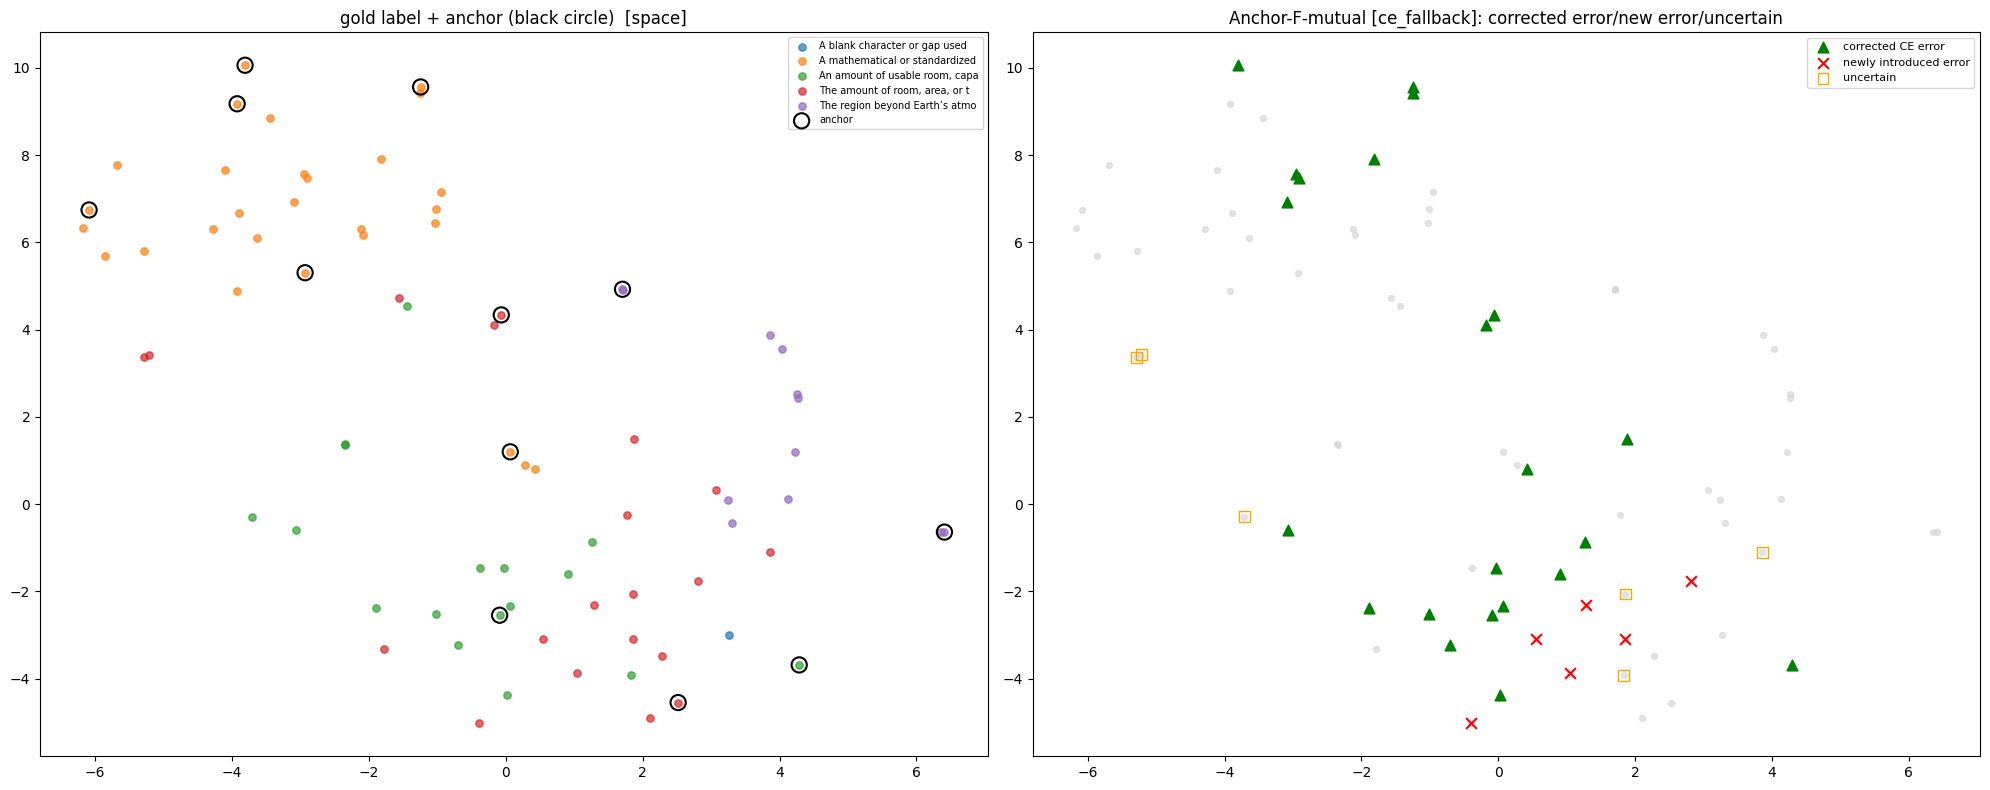

Full CE per-class F1:


,description,gold_count,f1
0,"A blank character or gap used in writing or printing to separate words, sentences, syllables, or other text elements.",1,0.000
1,"A mathematical or standardized system for representing colors as coordinates, models, or named mappings.",28,0.833
2,"An amount of usable room, capacity, or leftover area for something to fit, happen, or be stored.",17,0.105
3,"The amount of room, area, or three-dimensional extent available for objects, movement, or arrangement, including open areas and usable space.",20,0.500
4,"The region beyond Earth’s atmosphere, including the vacuum and space between celestial bodies.",12,0.558


Anchor-F-mutual [ce_fallback] per-class F1:


,description,gold_count,f1
0,"A blank character or gap used in writing or printing to separate words, sentences, syllables, or other text elements.",1,0.000
1,"A mathematical or standardized system for representing colors as coordinates, models, or named mappings.",28,0.903
2,"An amount of usable room, capacity, or leftover area for something to fit, happen, or be stored.",17,0.667
3,"The amount of room, area, or three-dimensional extent available for objects, movement, or arrangement, including open areas and usable space.",20,0.533
4,"The region beyond Earth’s atmosphere, including the vacuum and space between celestial bodies.",12,0.889


In [19]:
# ====== t-SNE 可视化：gold 类着色，标注 anchor / uncertain / 纠错 / 新错 ======
coords = reduce_embeddings(records, method=DEFAULT_REDUCTION_METHOD, random_state=DEFAULT_RANDOM_STATE)
record_indices = [r["record_index"] for r in records]
pos_of_index = {ri: p for p, ri in enumerate(record_indices)}

viz_version, viz_knn_type, viz_umode = "F", "mutual", "ce_fallback"
viz_method = anchor_method_name(viz_version, viz_knn_type, viz_umode)
viz_res = anchor_prop_results[anchor_prop_key(viz_version, viz_knn_type, viz_umode)]
viz_pred = viz_res["pred_by_index"]
viz_anchor = viz_res["anchor_index_set"]
viz_uncertain = viz_res["uncertain_index_set"]

gold_classes = sorted(set(gold_by_index.values()))
color_map = {c: plt.cm.tab10(k % 10) for k, c in enumerate(gold_classes)}

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# 左：gold 着色 + anchor 标记。
ax = axes[0]
for c in gold_classes:
    pts = [pos_of_index[i] for i in record_indices if gold_by_index[i] == c]
    ax.scatter(coords[pts, 0], coords[pts, 1], s=28, color=color_map[c], label=f"{c[:30]}", alpha=0.7)
anchor_pos = [pos_of_index[i] for i in viz_anchor]
ax.scatter(coords[anchor_pos, 0], coords[anchor_pos, 1], s=120, facecolors="none",
           edgecolors="black", linewidths=1.5, label="anchor")
ax.set_title(f"gold label + anchor (black circle)  [{TARGET_SPAN}]")
ax.legend(fontsize=7, loc="best")

# 右：选定 anchor 方法的纠错 / 新错 / uncertain。
ax = axes[1]
ax.scatter(coords[:, 0], coords[:, 1], s=18, color="lightgray", alpha=0.6)
corrected_pos = [pos_of_index[i] for i in record_indices
                 if ce_top1_by_index[i] != gold_by_index[i] and viz_pred.get(i) == gold_by_index[i]]
newly_pos = [pos_of_index[i] for i in record_indices
             if ce_top1_by_index[i] == gold_by_index[i] and viz_pred.get(i) != gold_by_index[i]]
uncertain_pos = [pos_of_index[i] for i in viz_uncertain]
ax.scatter(coords[corrected_pos, 0], coords[corrected_pos, 1], s=60, color="green", marker="^", label="corrected CE error")
ax.scatter(coords[newly_pos, 0], coords[newly_pos, 1], s=60, color="red", marker="x", label="newly introduced error")
ax.scatter(coords[uncertain_pos, 0], coords[uncertain_pos, 1], s=60, color="orange", marker="s", facecolors="none", label="uncertain")
ax.set_title(f"{viz_method}: corrected error/new error/uncertain")
ax.legend(fontsize=8, loc="best")

plt.tight_layout()
plt.show()

# per-class F1 对比（Full CE vs 当前可视化方法）。
print("Full CE per-class F1:")
display(per_class_f1_frame(ce_top1_by_index, gold_by_index))
print(f"{viz_method} per-class F1:")
display(per_class_f1_frame(viz_pred, gold_by_index))
